# 🏎️ F1 EDA & Feature Engineering — Master Dataset
**Flow:** `cleaned data` → EDA insights → feature validation → `master_dataset.csv`

### Nội dung:
1. Data overview
2. Lap time distribution & outlier analysis
3. Tyre cliff detection (compound degradation)
4. Spearman correlation heatmap
5. Win rate imbalance & SMOTE rationale
6. VIF — Multicollinearity check
7. Interaction plots (compound × track_temp)
8. Feature validation sau khi engineering


In [2]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

CLEAN_DIR   = Path('../data/cleaned')
PROC_DIR    = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

def read(name):
    p = CLEAN_DIR / name
    return pd.read_csv(p, low_memory=False) if p.exists() else pd.DataFrame()

laps     = read('laps.csv')
sessions = read('sessions.csv')
drivers  = read('drivers.csv')
stints   = read('stints.csv')
weather  = read('weather.csv')
results  = read('session_results.csv')
print(f'Laps: {len(laps):,}  Sessions: {len(sessions)}  Stints: {len(stints):,}')


Laps: 82,535  Sessions: 180  Stints: 9,392


---
## 1️⃣ Data Overview

In [2]:
summary = pd.DataFrame({
    'rows': {k: len(v) for k, v in {'laps':laps,'sessions':sessions,'drivers':drivers,'stints':stints,'weather':weather,'results':results}.items()},
    'cols': {k: len(v.columns) for k, v in {'laps':laps,'sessions':sessions,'drivers':drivers,'stints':stints,'weather':weather,'results':results}.items()},
    'null_%': {k: round(v.isnull().values.mean()*100, 2) for k, v in {'laps':laps,'sessions':sessions,'drivers':drivers,'stints':stints,'weather':weather,'results':results}.items()},
})
print('=== Dataset Summary ===')
display(summary.style.background_gradient(cmap='Reds', subset=['null_%']))


=== Dataset Summary ===


,rows,cols,null_%
laps,82535,25,0.050000
sessions,180,15,0.000000
drivers,3717,12,0.000000
stints,9392,9,0.050000
weather,15182,17,0.000000
results,2784,12,6.510000


---
## 2️⃣ Lap Time Analysis
### Histogram + Boxplot (F1 domain: 60s–120s per lap, outliers = SC/accident)

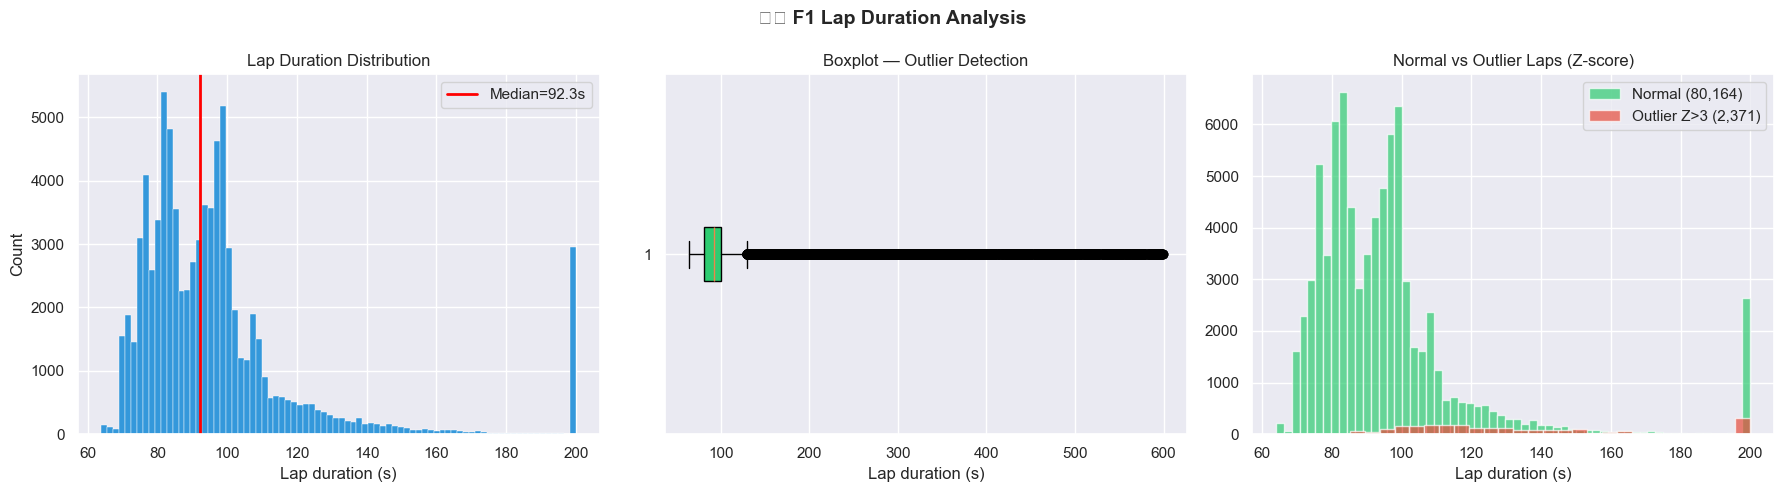

In [3]:
if 'lap_duration' not in laps.columns or laps.empty:
    print('No lap_duration data')
else:
    ld = laps['lap_duration'].dropna()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram
    axes[0].hist(ld.clip(upper=200), bins=80, color='#3498db', edgecolor='white', linewidth=0.3)
    axes[0].axvline(ld.median(), color='red', lw=2, label=f'Median={ld.median():.1f}s')
    axes[0].set_xlabel('Lap duration (s)'); axes[0].set_ylabel('Count')
    axes[0].set_title('Lap Duration Distribution')
    axes[0].legend()

    # Boxplot
    axes[1].boxplot(ld, vert=False, patch_artist=True, boxprops=dict(facecolor='#2ecc71'))
    axes[1].set_xlabel('Lap duration (s)'); axes[1].set_title('Boxplot — Outlier Detection')

    # is_outlier_lap if exists
    if 'is_outlier_lap' in laps.columns:
        laps['is_outlier_lap'] = laps['is_outlier_lap'].astype(bool)
        normal = laps.loc[~laps['is_outlier_lap'], 'lap_duration'].dropna()
        outlier = laps.loc[laps['is_outlier_lap'], 'lap_duration'].dropna()
        axes[2].hist(normal.clip(upper=200), bins=60, alpha=0.7, label=f'Normal ({len(normal):,})', color='#2ecc71')
        axes[2].hist(outlier.clip(upper=200), bins=30, alpha=0.7, label=f'Outlier Z>3 ({len(outlier):,})', color='#e74c3c')
        axes[2].set_xlabel('Lap duration (s)'); axes[2].set_title('Normal vs Outlier Laps (Z-score)')
        axes[2].legend()
    else:
        axes[2].set_visible(False)

    plt.suptitle('🏎️ F1 Lap Duration Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


---
## 3️⃣ Tyre Cliff Detection
> **F1 Domain:** Mỗi loại lốp có điểm 'cliff' — sau đó hiệu suất sụt giảm đột ngột.
SOFT cliff ~20-25 laps, MEDIUM ~30-35, HARD ~40-50.

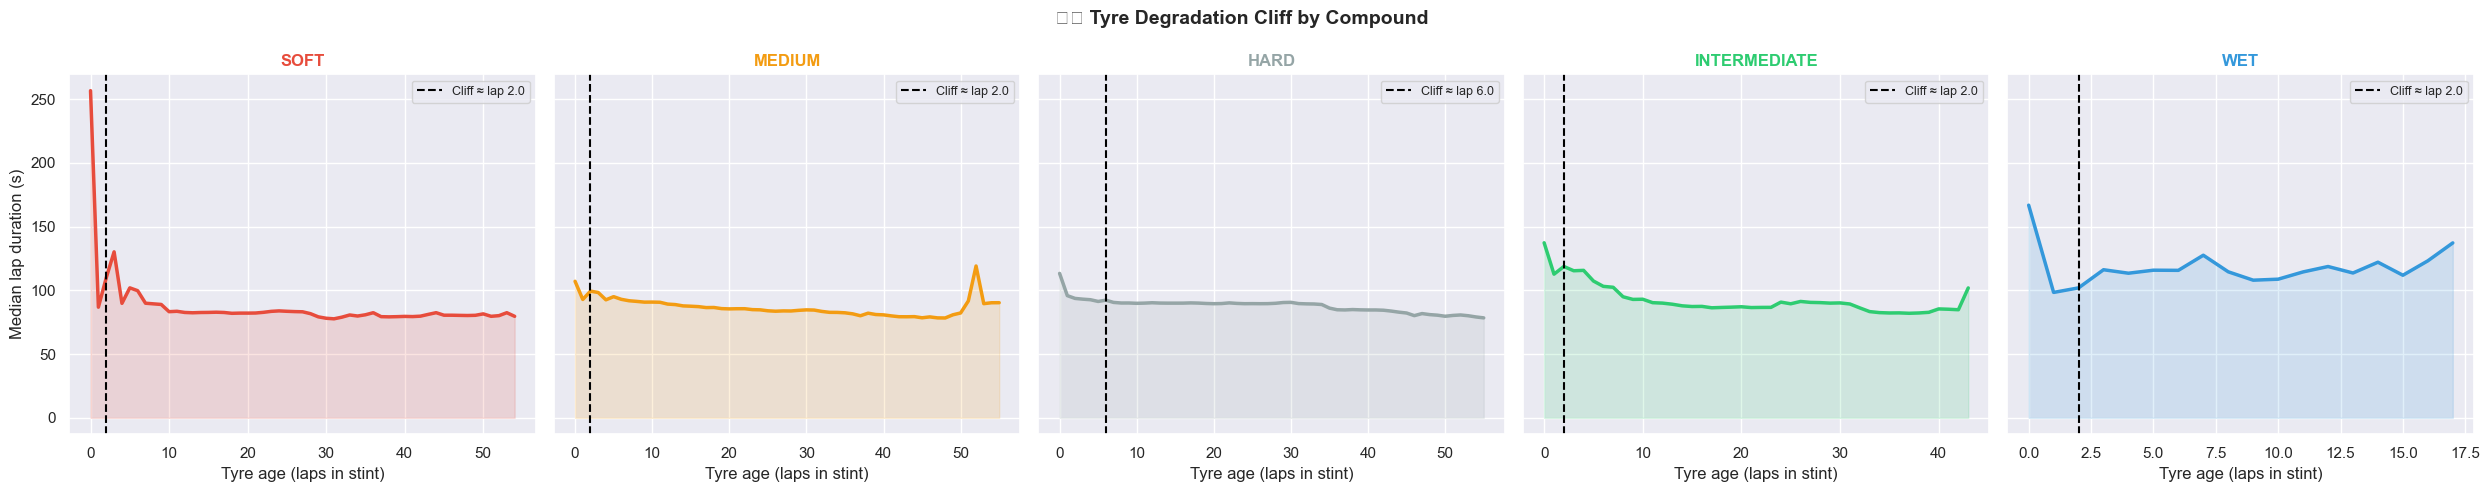

In [4]:
if stints.empty or laps.empty:
    print('Need stints + laps data')
else:
    needed_s = {'session_key','driver_number','lap_start','lap_end','compound','tyre_age_at_start'}
    needed_l = {'session_key','driver_number','lap_number','lap_duration'}
    if needed_s.issubset(stints.columns) and needed_l.issubset(laps.columns):
        merged = laps[list(needed_l)].merge(stints[list(needed_s)], on=['session_key','driver_number'], how='left')
        merged = merged[(merged['lap_number']>=merged['lap_start'].fillna(-1)) & (merged['lap_number']<=merged['lap_end'].fillna(9999))].copy()
        merged['tyre_age'] = (merged['lap_number'] - merged['lap_start'] + merged['tyre_age_at_start'].fillna(0)).clip(lower=0)
        merged['compound'] = merged['compound'].fillna('UNKNOWN').str.upper()

        CLIFF_COLORS = {'SOFT':'#e74c3c','MEDIUM':'#f39c12','HARD':'#95a5a6','INTERMEDIATE':'#2ecc71','WET':'#3498db'}
        compounds = [c for c in ['SOFT','MEDIUM','HARD','INTERMEDIATE','WET'] if c in merged['compound'].values]

        fig, axes = plt.subplots(1, len(compounds), figsize=(5*len(compounds), 5), sharey=True)
        if len(compounds)==1: axes=[axes]

        for ax, compound in zip(axes, compounds):
            cdf = merged[merged['compound']==compound].copy()
            if len(cdf) < 20: ax.set_title(f'{compound}\n(insufficient data)'); continue
            perf = cdf.groupby('tyre_age')['lap_duration'].median().reset_index()
            perf = perf[perf['tyre_age'].between(0, 55)]
            color = CLIFF_COLORS.get(compound, '#7f8c8d')
            ax.plot(perf['tyre_age'], perf['lap_duration'], color=color, lw=2.5)
            ax.fill_between(perf['tyre_age'], perf['lap_duration'], alpha=0.15, color=color)
            # Detect cliff
            pct = perf.set_index('tyre_age')['lap_duration'].pct_change()
            cliff_laps = pct[pct > 0.01].index
            if len(cliff_laps) > 0:
                cliff = cliff_laps[0]
                ax.axvline(cliff, color='black', ls='--', lw=1.5, label=f'Cliff ≈ lap {cliff}')
                ax.legend(fontsize=9)
            ax.set_title(f'{compound}', color=color, fontweight='bold')
            ax.set_xlabel('Tyre age (laps in stint)')
            if ax == axes[0]: ax.set_ylabel('Median lap duration (s)')

        plt.suptitle('🏎️ Tyre Degradation Cliff by Compound', fontsize=14, fontweight='bold')
        plt.tight_layout(); plt.show()
    else:
        print('Missing required columns in stints/laps')


---
## 4️⃣ Spearman Correlation Heatmap
> Spearman phù hợp hơn Pearson cho dữ liệu F1 (không tuân phân phối chuẩn).

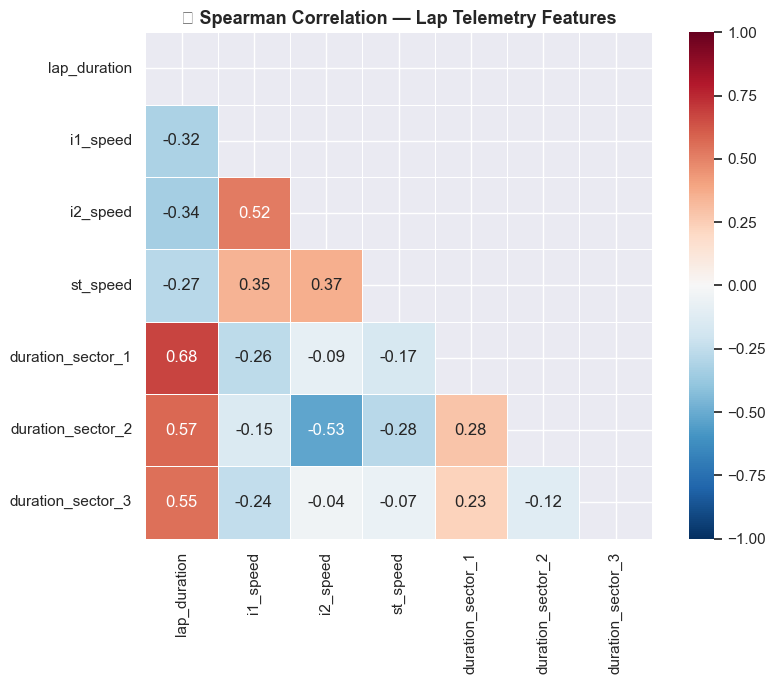

🔍 Interpretation: |r| > 0.7 = strong, |r| < 0.3 = weak


In [5]:
CORR_COLS = ['lap_duration','i1_speed','i2_speed','st_speed',
             'duration_sector_1','duration_sector_2','duration_sector_3']
corr_cols = [c for c in CORR_COLS if c in laps.columns]
if len(corr_cols) >= 3:
    corr = laps[corr_cols].dropna().sample(min(5000,len(laps)), random_state=42).corr(method='spearman')
    fig, ax = plt.subplots(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                mask=mask, ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1)
    ax.set_title('🔥 Spearman Correlation — Lap Telemetry Features', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('🔍 Interpretation: |r| > 0.7 = strong, |r| < 0.3 = weak')
else:
    print('Not enough columns for correlation')


---
## 5️⃣ Win Rate Imbalance (F1: 1/20 = 5%)

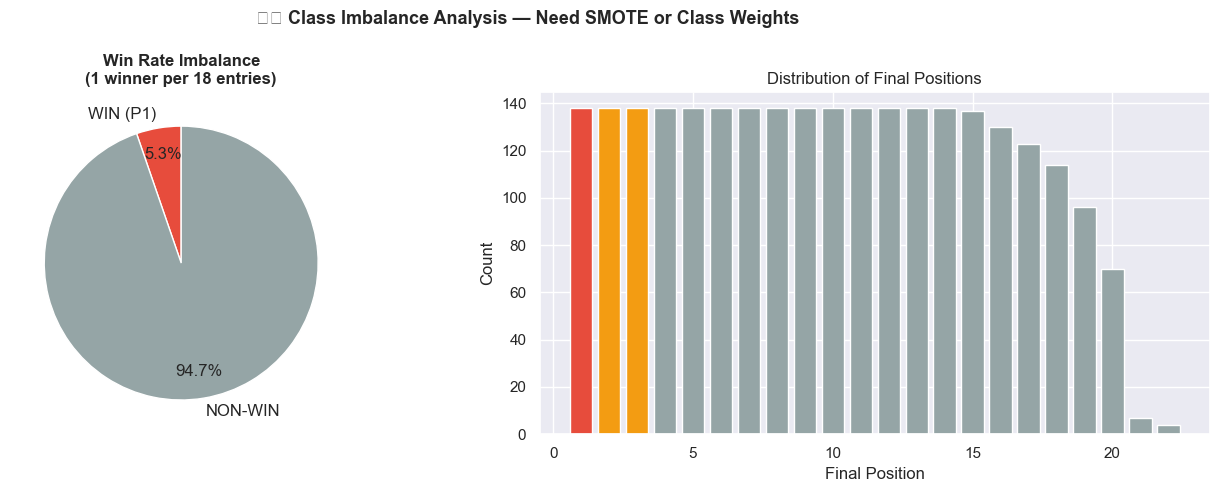

Win rate: 0.053 → Recommend: class_weight={0: 1, 1: 18} or SMOTE


In [6]:
if not results.empty and 'position' in results.columns:
    pos = pd.to_numeric(results['position'], errors='coerce')
    wins = (pos == 1).sum()
    total = pos.notna().sum()
    win_rate = wins / total

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Pie chart
    axes[0].pie([wins, total-wins], labels=['WIN (P1)', 'NON-WIN'],
                colors=['#e74c3c','#95a5a6'], autopct='%1.1f%%',
                startangle=90, pctdistance=0.8, textprops={'fontsize':12})
    axes[0].set_title(f'Win Rate Imbalance\n(1 winner per {int(1/win_rate):.0f} entries)', fontweight='bold')

    # Position distribution
    pos_counts = pos.dropna().astype(int).value_counts().sort_index()
    colors = ['#e74c3c' if i==1 else '#f39c12' if i<=3 else '#95a5a6' for i in pos_counts.index]
    axes[1].bar(pos_counts.index, pos_counts.values, color=colors, edgecolor='white')
    axes[1].set_xlabel('Final Position'); axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of Final Positions')

    plt.suptitle('⚖️ Class Imbalance Analysis — Need SMOTE or Class Weights', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Win rate: {win_rate:.3f} → Recommend: class_weight={{0: 1, 1: {int(1/win_rate)}}} or SMOTE')
else:
    print('No results data available')


---
## 6️⃣ VIF — Multicollinearity Check
> VIF > 10 → biến đó bị đa cộng tuyến nặng, cân nhắc xóa hoặc combine.

In [7]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    VIF_COLS = [c for c in ['lap_duration','i1_speed','i2_speed','st_speed',
                             'duration_sector_1','duration_sector_2','duration_sector_3'] if c in laps.columns]
    vif_df = laps[VIF_COLS].dropna().sample(min(3000, len(laps)), random_state=42)
    vif_vals = pd.DataFrame({
        'feature': VIF_COLS,
        'VIF': [variance_inflation_factor(vif_df.values, i) for i in range(len(VIF_COLS))]
    }).sort_values('VIF', ascending=False)
    vif_vals['risk'] = vif_vals['VIF'].apply(lambda v: '🔴 HIGH' if v>10 else '🟡 MEDIUM' if v>5 else '🟢 OK')
    display(vif_vals.style.background_gradient(cmap='RdYlGn_r', subset=['VIF']))
    print('Recommendation: If VIF>10, consider dropping or creating derivative (e.g. Acceleration = Δspeed/Δtime)')
except ImportError:
    print('Install statsmodels: pip install statsmodels')


Install statsmodels: pip install statsmodels


---
## 7️⃣ Interaction Plot: Compound × Track Temperature → Lap Time

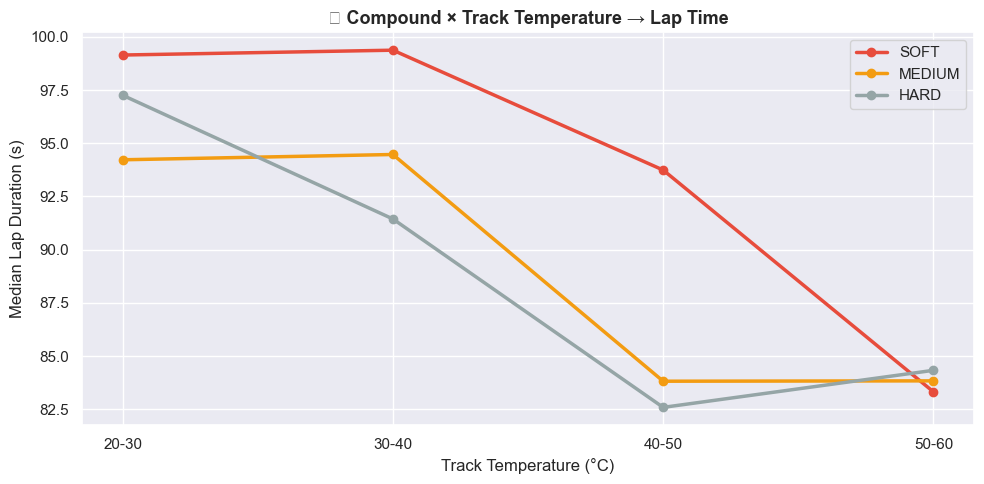

Insight: Softer tyres degrade faster in high track temps — interaction is a strong ML signal


In [8]:
if not stints.empty and not weather.empty and 'date_start' in laps.columns:
    needed_s = {'session_key','driver_number','lap_start','lap_end','compound'}
    if needed_s.issubset(stints.columns) and 'track_temperature' in weather.columns:
        # Quick merge for interaction
        lap_stint = laps.merge(stints[list(needed_s)], on=['session_key','driver_number'], how='left')
        lap_stint = lap_stint[(lap_stint['lap_number']>=lap_stint['lap_start'].fillna(-1)) &
                               (lap_stint['lap_number']<=lap_stint['lap_end'].fillna(9999))].copy()
        lap_stint['compound'] = lap_stint['compound'].fillna('UNKNOWN').str.upper()
        # Join weather (session-level mean)
        weather_mean = weather.groupby('session_key')['track_temperature'].mean().reset_index()
        lap_stint = lap_stint.merge(weather_mean, on='session_key', how='left')
        lap_stint['temp_bin'] = pd.cut(lap_stint['track_temperature'], bins=[20,30,40,50,60], labels=['20-30','30-40','40-50','50-60'])

        pivot = lap_stint.groupby(['compound','temp_bin'], observed=True)['lap_duration'].median().unstack('temp_bin')
        compounds_show = [c for c in ['SOFT','MEDIUM','HARD'] if c in pivot.index]
        if compounds_show and not pivot.empty:
            fig, ax = plt.subplots(figsize=(10, 5))
            colors = {'SOFT':'#e74c3c','MEDIUM':'#f39c12','HARD':'#95a5a6'}
            for compound in compounds_show:
                row = pivot.loc[compound].dropna()
                ax.plot(row.index.astype(str), row.values, marker='o', lw=2.5,
                        label=compound, color=colors.get(compound,'gray'))
            ax.set_xlabel('Track Temperature (°C)'); ax.set_ylabel('Median Lap Duration (s)')
            ax.set_title('🔥 Compound × Track Temperature → Lap Time', fontsize=13, fontweight='bold')
            ax.legend(); plt.tight_layout(); plt.show()
            print('Insight: Softer tyres degrade faster in high track temps — interaction is a strong ML signal')
        else:
            print('Insufficient compound/temperature combinations')
    else:
        print('Missing required columns')
else:
    print('Run pipeline first to get stints + weather data')


---
## 8️⃣ Run Feature Engineering & Validate Output

In [9]:
from src.feature_engineering import build_feature_engineering
import os
os.chdir('..')  # ensure project root

print('Running feature engineering...')
master = build_feature_engineering()
print(f'Master dataset: {master.shape}')
display(master.head(3))


Running feature engineering...


2026-06-15 03:24:03,048 | INFO | src.feature_engineering | Base laps: 82,535 rows
2026-06-15 03:24:03,158 | INFO | src.feature_engineering |   Tyre cliff [MEDIUM]: learned=48 domain=33 → blended=42
2026-06-15 03:24:03,169 | INFO | src.feature_engineering |   Tyre cliff [SOFT]: learned=2 domain=22 → blended=10
2026-06-15 03:24:03,188 | INFO | src.feature_engineering |   Tyre cliff [INTERMEDIATE]: learned=22 domain=20 → blended=21
2026-06-15 03:24:03,196 | INFO | src.feature_engineering |   Tyre cliff [WET]: learned=2 domain=15 → blended=7
2026-06-15 03:24:03,204 | INFO | src.feature_engineering |   Tyre cliff [UNKNOWN]: learned=10 domain=30 → blended=18
2026-06-15 03:24:03,205 | INFO | src.feature_engineering | Tyre cliffs: {'SOFT': 10, 'MEDIUM': 42, 'HARD': 45, 'INTERMEDIATE': 21, 'WET': 7, 'UNKNOWN': 18}
2026-06-15 03:24:03,584 | INFO | src.feature_engineering | Stint features added
2026-06-15 03:24:07,440 | INFO | src.feature_engineering | Rolling features added
2026-06-15 03:24:08,0

Master dataset: (82099, 81)


,session_key,driver_number,lap_number,meeting_key,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,...,tele_prev_speed_std,tele_prev_throttle_mean,tele_prev_throttle_q90,tele_prev_brake_mean,tele_prev_brake_sum,tele_prev_rpm_mean,tele_prev_rpm_std,tele_prev_ngear_mean,tele_prev_ngear_max,tele_prev_drs_sum
0,9468,1,2,1229,2024-03-01 16:08:56.691000+00:00,28.787,38.580,22.664,242.0,270.0,...,86.787924,45.130818,100.0,0.184341,186.0,8664.690758,2950.460154,3.320119,8.0,8264.0
1,9468,1,3,1229,2024-03-01 16:10:26.704000+00:00,37.524,56.168,35.034,153.0,168.0,...,68.254698,70.948914,100.0,0.184325,127.0,10210.634799,1557.268148,5.447025,8.0,6180.0
2,9468,1,4,1229,2024-03-01 16:15:53.763000+00:00,28.822,46.144,29.156,174.0,238.0,...,51.066269,30.388891,64.0,0.215863,215.0,9099.576997,1385.920088,3.757028,8.0,7994.0


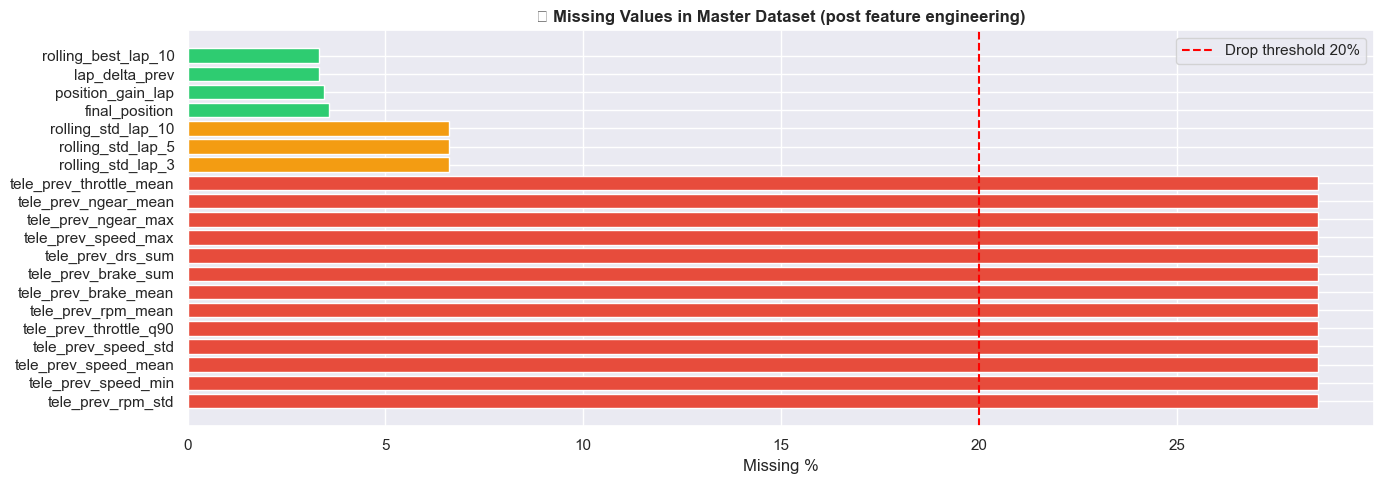

In [10]:
# Feature validation: show missing % after engineering
miss = (master.isnull().mean()*100).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if v>20 else '#f39c12' if v>5 else '#2ecc71' for v in miss.values]
ax.barh(miss.index, miss.values, color=colors)
ax.axvline(20, color='red', ls='--', label='Drop threshold 20%')
ax.set_xlabel('Missing %')
ax.set_title('📊 Missing Values in Master Dataset (post feature engineering)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


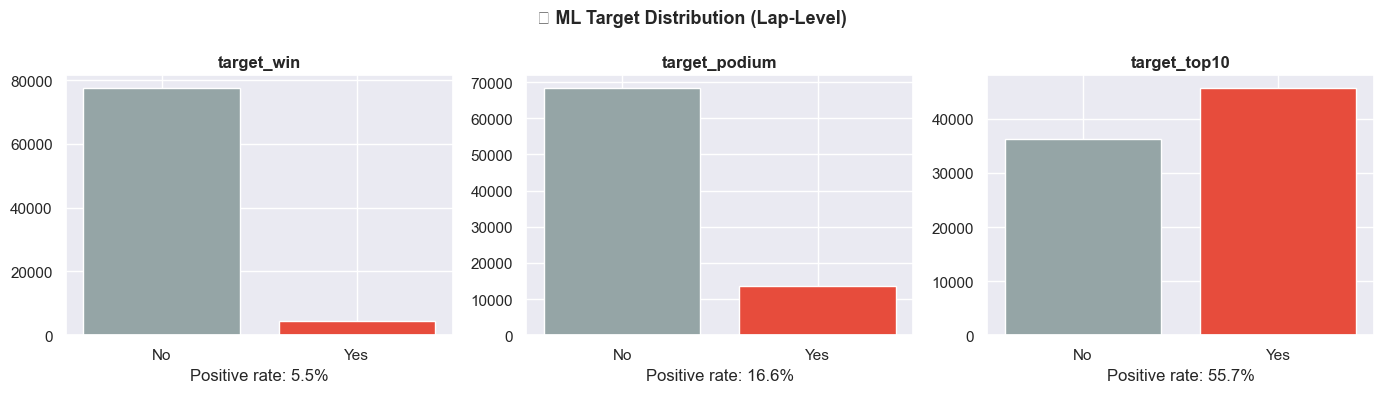

In [11]:
# Target distribution
if 'target_win' in master.columns:
    targets = ['target_win','target_podium','target_top10']
    targets = [t for t in targets if t in master.columns]
    fig, axes = plt.subplots(1, len(targets), figsize=(14, 4))
    if len(targets)==1: axes=[axes]
    for ax, t in zip(axes, targets):
        vals = master[t].dropna().astype(int).value_counts().sort_index()
        ax.bar(vals.index, vals.values, color=['#95a5a6','#e74c3c'], edgecolor='white')
        ax.set_xticks([0,1]); ax.set_xticklabels(['No','Yes'])
        ax.set_title(t, fontweight='bold')
        rate = vals.get(1,0)/vals.sum()
        ax.set_xlabel(f'Positive rate: {rate:.1%}')
    plt.suptitle('🎯 ML Target Distribution (Lap-Level)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


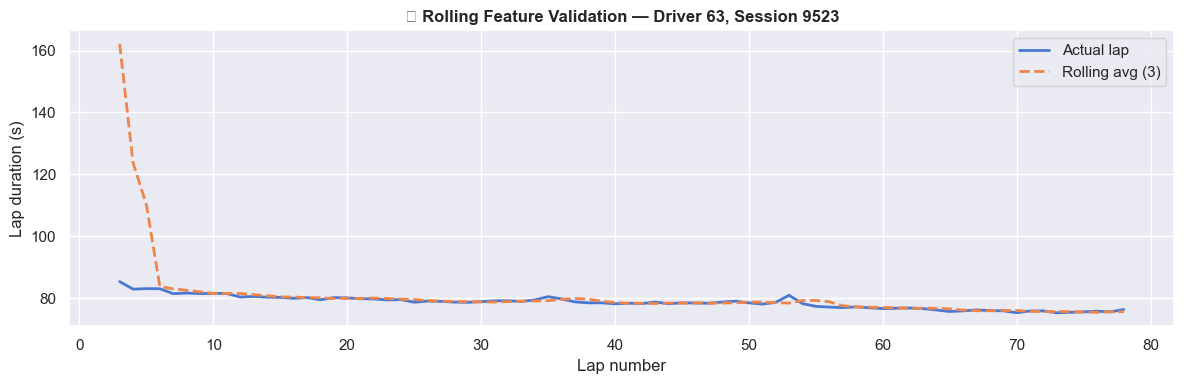

✅ Rolling avg is smoother than actual — no future leak (shift(1) applied)


In [12]:
# Rolling feature sanity check: plot avg lap_3 vs lap_duration for 1 driver
if 'rolling_avg_lap_3' in master.columns:
    sample = master.dropna(subset=['lap_duration','rolling_avg_lap_3'])
    if not sample.empty:
        drv = sample['driver_number'].value_counts().index[0]
        sk  = sample[sample['driver_number']==drv]['session_key'].value_counts().index[0]
        drv_df = sample[(sample['driver_number']==drv)&(sample['session_key']==sk)].sort_values('lap_number')
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(drv_df['lap_number'], drv_df['lap_duration'], label='Actual lap', lw=2)
        ax.plot(drv_df['lap_number'], drv_df['rolling_avg_lap_3'], label='Rolling avg (3)', lw=2, ls='--')
        ax.set_xlabel('Lap number'); ax.set_ylabel('Lap duration (s)')
        ax.set_title(f'📈 Rolling Feature Validation — Driver {drv}, Session {sk}', fontweight='bold')
        ax.legend(); plt.tight_layout(); plt.show()
        print('✅ Rolling avg is smoother than actual — no future leak (shift(1) applied)')


---
## ✅ Summary
| Feature Group | Count | Tình trạng |
|---|---|---|
| Rolling window (3/5/10 laps) | 9 cols | ✅ |
| Tyre features (age, cliff, compound) | 5 cols | ✅ |
| Weather (temp, humidity, evolution) | 5+ cols | ✅ |
| Position features | 4 cols | ✅ |
| Race progress (completion%, laps_to_go) | 2 cols | ✅ |
| ML targets | 3 cols | ✅ |

**Next step:** Feature Selection (VIF + Spearman) → Encoding → Train/Test Split → Modeling


In [13]:
if 'target_win' in master.columns:
    print(f'Master dataset ready for modeling:')
    print(f'  Shape: {master.shape}')
    print(f'  Win rate: {master["target_win"].mean():.3%}')
    print(f'  Saved to: data/processed/master_dataset.csv')
    print(f'  Columns: {list(master.columns)}')


Master dataset ready for modeling:
  Shape: (82099, 81)
  Win rate: 5.530%
  Saved to: data/processed/master_dataset.csv
  Columns: ['session_key', 'driver_number', 'lap_number', 'meeting_key', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap', 'lap_duration', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3', 'st_speed', 'is_missing_lap_duration', 'is_invalid_lap_duration', 'is_outlier_lap', 'is_invalid_i1_speed', 'is_invalid_i2_speed', 'is_invalid_st_speed', 'is_invalid_duration_sector_1', 'is_invalid_duration_sector_2', 'is_invalid_duration_sector_3', 'year', 'session_type', 'circuit_key', 'circuit_short_name', 'country_name', 'date_start_sess', 'date_end', 'full_name', 'name_acronym', 'team_name', 'stint_number', 'compound', 'current_tyre_age', 'compound_cliff', 'laps_until_cliff', 'is_past_cliff', 'rolling_avg_lap_3', 'rolling_std_lap_3', 'rolling_best_lap_3', 'rolling_avg_lap_5', 'rolling_std_lap_5', 

In [14]:
# Tyre cliff summary table
from src.feature_engineering import learn_tyre_cliffs, _read
from pathlib import Path
cliffs = learn_tyre_cliffs(stints, laps)
cliff_df = pd.DataFrame([{'Compound':k,'Cliff Lap':v,'Meaning':f'After lap {v} in stint → performance drops'} for k,v in cliffs.items()])
print('=== Learned Tyre Cliff Points ===')
display(cliff_df.style.set_caption('Hybrid: 60% data-learned + 40% domain knowledge'))


2026-06-15 03:24:59,526 | INFO | src.feature_engineering |   Tyre cliff [MEDIUM]: learned=48 domain=33 → blended=42
2026-06-15 03:24:59,536 | INFO | src.feature_engineering |   Tyre cliff [SOFT]: learned=2 domain=22 → blended=10
2026-06-15 03:24:59,553 | INFO | src.feature_engineering |   Tyre cliff [INTERMEDIATE]: learned=22 domain=20 → blended=21
2026-06-15 03:24:59,561 | INFO | src.feature_engineering |   Tyre cliff [WET]: learned=2 domain=15 → blended=7
2026-06-15 03:24:59,571 | INFO | src.feature_engineering |   Tyre cliff [UNKNOWN]: learned=10 domain=30 → blended=18


=== Learned Tyre Cliff Points ===


,Compound,Cliff Lap,Meaning
0,SOFT,10,After lap 10 in stint → performance drops
1,MEDIUM,42,After lap 42 in stint → performance drops
2,HARD,45,After lap 45 in stint → performance drops
3,INTERMEDIATE,21,After lap 21 in stint → performance drops
4,WET,7,After lap 7 in stint → performance drops
5,UNKNOWN,18,After lap 18 in stint → performance drops



---
# Deep Feature Engineering EDA

This section extends the original feature-engineering EDA with endpoint-level diagnostics, cross-endpoint feature insight, and ML-readiness checks.

Design principles:
- Keep endpoint grain explicit before joining.
- Use sampling for high-volume telemetry/location data.
- Treat `session_results` as label/result data, not ordinary features.
- Prefer plots that answer feature-engineering questions, not decorative summaries.


In [15]:

import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq

from src.feature_engineering import build_feature_engineering

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

CLEAN_DIR = PROJECT_ROOT / "data" / "cleaned"
PROC_DIR = PROJECT_ROOT / "data" / "processed"

CSV_ENDPOINTS = [
    "sessions", "meetings", "drivers", "session_results", "starting_grid",
    "laps", "stints", "weather", "intervals", "position",
    "race_control", "pit", "overtakes", "team_radio",
]
PARQUET_ENDPOINTS = ["car_data", "location"]

def read_csv_endpoint(name):
    path = CLEAN_DIR / f"{name}.csv"
    return pd.read_csv(path, low_memory=False) if path.exists() else pd.DataFrame()

def parquet_meta(name):
    path = CLEAN_DIR / f"{name}.parquet"
    if not path.exists():
        return {"rows": 0, "cols": 0, "columns": []}
    pf = pq.ParquetFile(path)
    return {"rows": pf.metadata.num_rows, "cols": len(pf.schema_arrow.names), "columns": pf.schema_arrow.names}

dfs = {name: read_csv_endpoint(name) for name in CSV_ENDPOINTS}
sessions = dfs["sessions"]
meetings = dfs["meetings"]
drivers = dfs["drivers"]
results = dfs["session_results"]
grid = dfs["starting_grid"]
laps = dfs["laps"]
stints = dfs["stints"]
weather = dfs["weather"]
intervals = dfs["intervals"]
position = dfs["position"]
race_control = dfs["race_control"]
pit = dfs["pit"]
overtakes = dfs["overtakes"]
team_radio = dfs["team_radio"]

for df in dfs.values():
    for col in ["date", "date_start", "date_end"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

print("Loaded cleaned CSV endpoints:")
display(pd.DataFrame({
    "endpoint": list(dfs.keys()),
    "rows": [len(df) for df in dfs.values()],
    "cols": [len(df.columns) for df in dfs.values()],
    "null_pct": [round(df.isna().mean().mean() * 100, 2) if not df.empty else np.nan for df in dfs.values()],
}))
print("Parquet metadata:")
display(pd.DataFrame([{"endpoint": name, **parquet_meta(name)} for name in PARQUET_ENDPOINTS]).drop(columns=["columns"]))


Loaded cleaned CSV endpoints:


,endpoint,rows,cols,null_pct
0,sessions,180,15,0.00
1,meetings,72,18,0.00
2,drivers,3717,12,0.00
3,session_results,2784,12,6.51
4,starting_grid,1377,6,0.65
5,laps,82535,25,0.05
6,stints,9392,9,0.05
7,weather,15182,17,0.00
8,intervals,1422363,10,1.08
9,position,116856,6,0.00


Parquet metadata:


,endpoint,rows,cols
0,car_data,85151808,28
1,location,43062384,12



## 0. Run / Load Master Dataset

`build_feature_engineering()` is allowed here so the notebook can inspect the actual final feature table. If it is expensive in your environment, set `RUN_FEATURE_ENGINEERING = False` and load existing `data/processed/master_dataset.csv`.


In [16]:

RUN_FEATURE_ENGINEERING = True

if RUN_FEATURE_ENGINEERING:
    master = build_feature_engineering()
else:
    master_path = PROC_DIR / "master_dataset.csv"
    master = pd.read_csv(master_path, low_memory=False) if master_path.exists() else pd.DataFrame()

print(f"master shape: {master.shape}")
display(master.head(3))


2026-06-15 03:25:03,746 | INFO | src.feature_engineering | Base laps: 82,535 rows
2026-06-15 03:25:03,839 | INFO | src.feature_engineering |   Tyre cliff [MEDIUM]: learned=48 domain=33 → blended=42
2026-06-15 03:25:03,849 | INFO | src.feature_engineering |   Tyre cliff [SOFT]: learned=2 domain=22 → blended=10
2026-06-15 03:25:03,866 | INFO | src.feature_engineering |   Tyre cliff [INTERMEDIATE]: learned=22 domain=20 → blended=21
2026-06-15 03:25:03,874 | INFO | src.feature_engineering |   Tyre cliff [WET]: learned=2 domain=15 → blended=7
2026-06-15 03:25:03,880 | INFO | src.feature_engineering |   Tyre cliff [UNKNOWN]: learned=10 domain=30 → blended=18
2026-06-15 03:25:03,884 | INFO | src.feature_engineering | Tyre cliffs: {'SOFT': 10, 'MEDIUM': 42, 'HARD': 45, 'INTERMEDIATE': 21, 'WET': 7, 'UNKNOWN': 18}
2026-06-15 03:25:04,235 | INFO | src.feature_engineering | Stint features added
2026-06-15 03:25:07,871 | INFO | src.feature_engineering | Rolling features added
2026-06-15 03:25:08,4

master shape: (82099, 81)


,session_key,driver_number,lap_number,meeting_key,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,...,tele_prev_speed_std,tele_prev_throttle_mean,tele_prev_throttle_q90,tele_prev_brake_mean,tele_prev_brake_sum,tele_prev_rpm_mean,tele_prev_rpm_std,tele_prev_ngear_mean,tele_prev_ngear_max,tele_prev_drs_sum
0,9468,1,2,1229,2024-03-01 16:08:56.691000+00:00,28.787,38.580,22.664,242.0,270.0,...,86.787924,45.130818,100.0,0.184341,186.0,8664.690758,2950.460154,3.320119,8.0,8264.0
1,9468,1,3,1229,2024-03-01 16:10:26.704000+00:00,37.524,56.168,35.034,153.0,168.0,...,68.254698,70.948914,100.0,0.184325,127.0,10210.634799,1557.268148,5.447025,8.0,6180.0
2,9468,1,4,1229,2024-03-01 16:15:53.763000+00:00,28.822,46.144,29.156,174.0,238.0,...,51.066269,30.388891,64.0,0.215863,215.0,9099.576997,1385.920088,3.757028,8.0,7994.0


## 1. Coverage, Grain, And Missingness

,endpoint,grain,rows,cols,null_pct,sessions,drivers
14,car_data,driver sub-second telemetry,85151808,28,NaN,NaN,NaN
15,location,driver sub-second GPS,43062384,12,NaN,NaN,NaN
8,intervals,driver time-series,1422363,10,1.08,69.0,31.0
9,position,driver time-series,116856,6,0.00,138.0,31.0
5,laps,driver-lap,82535,25,0.05,137.0,31.0
7,weather,session time-series,15182,17,0.00,138.0,NaN
12,overtakes,event,14118,6,0.01,69.0,NaN
10,race_control,session event,9451,13,31.45,138.0,29.0
6,stints,driver-stint,9392,9,0.05,138.0,37.0
11,pit,driver event,8057,11,16.34,134.0,31.0


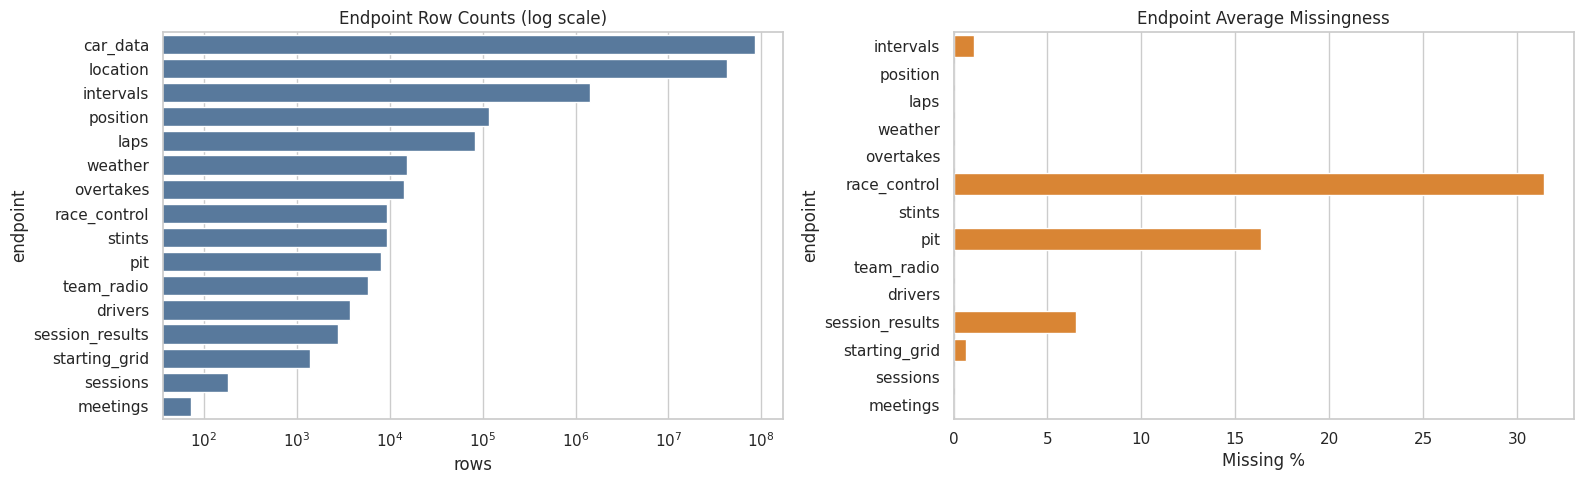

In [17]:

grain_map = {
    "sessions": "session",
    "meetings": "meeting",
    "drivers": "driver-session",
    "session_results": "driver-session label/result",
    "starting_grid": "driver-session pre-session",
    "laps": "driver-lap",
    "stints": "driver-stint",
    "weather": "session time-series",
    "intervals": "driver time-series",
    "position": "driver time-series",
    "race_control": "session event",
    "pit": "driver event",
    "overtakes": "event",
    "team_radio": "driver event",
    "car_data": "driver sub-second telemetry",
    "location": "driver sub-second GPS",
}

summary_rows = []
for name, df in dfs.items():
    summary_rows.append({
        "endpoint": name,
        "grain": grain_map.get(name, "unknown"),
        "rows": len(df),
        "cols": len(df.columns),
        "null_pct": round(df.isna().mean().mean() * 100, 2) if not df.empty else np.nan,
        "sessions": df["session_key"].nunique() if "session_key" in df.columns else np.nan,
        "drivers": df["driver_number"].nunique() if "driver_number" in df.columns else np.nan,
    })
for name in PARQUET_ENDPOINTS:
    meta = parquet_meta(name)
    summary_rows.append({
        "endpoint": name,
        "grain": grain_map[name],
        "rows": meta["rows"],
        "cols": meta["cols"],
        "null_pct": np.nan,
        "sessions": np.nan,
        "drivers": np.nan,
    })

endpoint_summary = pd.DataFrame(summary_rows).sort_values("rows", ascending=False)
display(endpoint_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=endpoint_summary, y="endpoint", x="rows", ax=axes[0], color="#4C78A8")
axes[0].set_xscale("log")
axes[0].set_title("Endpoint Row Counts (log scale)")
sns.barplot(data=endpoint_summary.dropna(subset=["null_pct"]), y="endpoint", x="null_pct", ax=axes[1], color="#F58518")
axes[1].set_title("Endpoint Average Missingness")
axes[1].set_xlabel("Missing %")
plt.tight_layout()
plt.show()


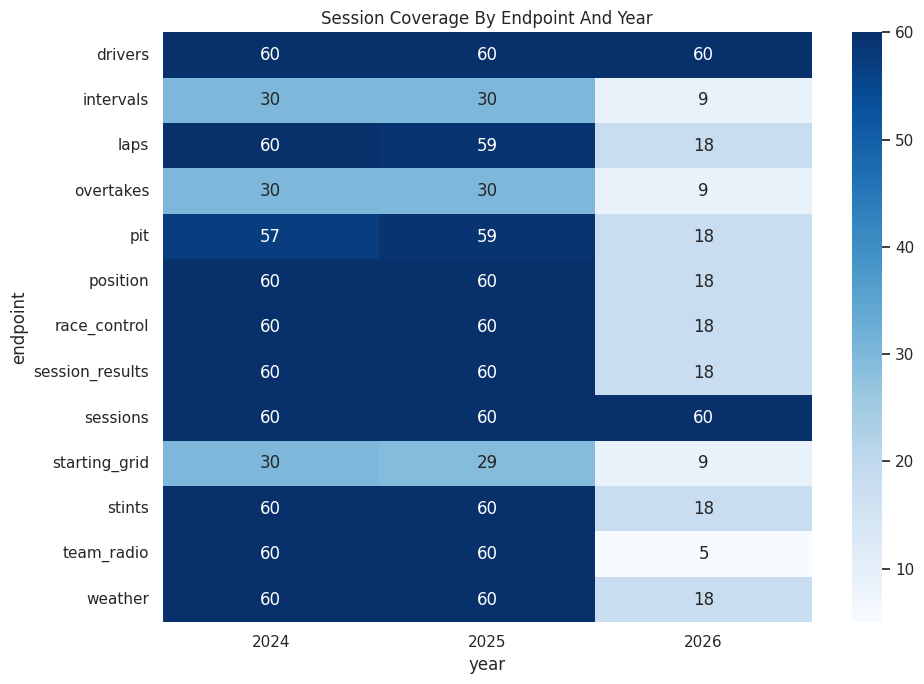

In [18]:

# Coverage by year/session type for endpoints with session_key
session_meta = sessions[[c for c in ["session_key", "year", "session_type", "circuit_short_name", "country_name"] if c in sessions.columns]].drop_duplicates("session_key")
coverage = []
for name, df in dfs.items():
    if "session_key" not in df.columns or df.empty:
        continue
    tmp = df[["session_key"]].drop_duplicates().merge(session_meta, on="session_key", how="left")
    for year, count in tmp.groupby("year")["session_key"].nunique().items():
        coverage.append({"endpoint": name, "year": year, "sessions": count})
coverage_df = pd.DataFrame(coverage)
if not coverage_df.empty:
    pivot = coverage_df.pivot_table(index="endpoint", columns="year", values="sessions", fill_value=0)
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax)
    ax.set_title("Session Coverage By Endpoint And Year")
    plt.tight_layout()
    plt.show()


,endpoint,keys,rows,unique_keys,duplicate_rows_on_key
0,sessions,session_key,180,180,0
1,meetings,meeting_key + year,72,72,0
2,drivers,session_key + driver_number,3717,3717,0
3,session_results,session_key + driver_number,2784,2784,0
4,starting_grid,session_key + driver_number,1377,1377,0
5,laps,session_key + driver_number + lap_number,82535,82535,0
6,stints,session_key + driver_number + stint_number,9392,9392,0
7,weather,session_key + date,15182,15182,0
8,intervals,session_key + driver_number + date,1422363,1422363,0
9,position,session_key + driver_number + date,116856,116856,0


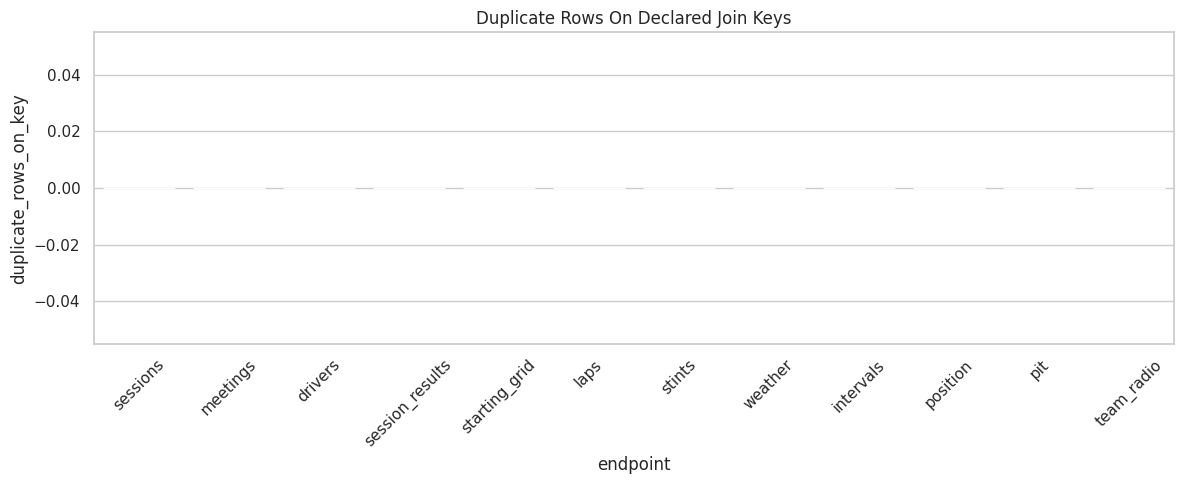

In [19]:

# Key uniqueness / row explosion risk audit
key_specs = {
    "sessions": ["session_key"],
    "meetings": ["meeting_key", "year"],
    "drivers": ["session_key", "driver_number"],
    "session_results": ["session_key", "driver_number"],
    "starting_grid": ["session_key", "driver_number"],
    "laps": ["session_key", "driver_number", "lap_number"],
    "stints": ["session_key", "driver_number", "stint_number"],
    "weather": ["session_key", "date"],
    "intervals": ["session_key", "driver_number", "date"],
    "position": ["session_key", "driver_number", "date"],
    "pit": ["session_key", "driver_number", "lap_number", "date"],
    "team_radio": ["session_key", "driver_number", "date"],
}
audit = []
for name, keys in key_specs.items():
    df = dfs.get(name, pd.DataFrame())
    keys = [k for k in keys if k in df.columns]
    if df.empty or not keys:
        continue
    audit.append({
        "endpoint": name,
        "keys": " + ".join(keys),
        "rows": len(df),
        "unique_keys": df[keys].drop_duplicates().shape[0],
        "duplicate_rows_on_key": int(df.duplicated(keys).sum()),
    })
audit_df = pd.DataFrame(audit)
display(audit_df.sort_values("duplicate_rows_on_key", ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=audit_df, x="endpoint", y="duplicate_rows_on_key", ax=ax, color="#E45756")
ax.tick_params(axis="x", rotation=45)
ax.set_title("Duplicate Rows On Declared Join Keys")
plt.tight_layout()
plt.show()


## 2. Sessions And Meetings EDA

2026-06-15 03:26:00,342 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 03:26:00,347 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


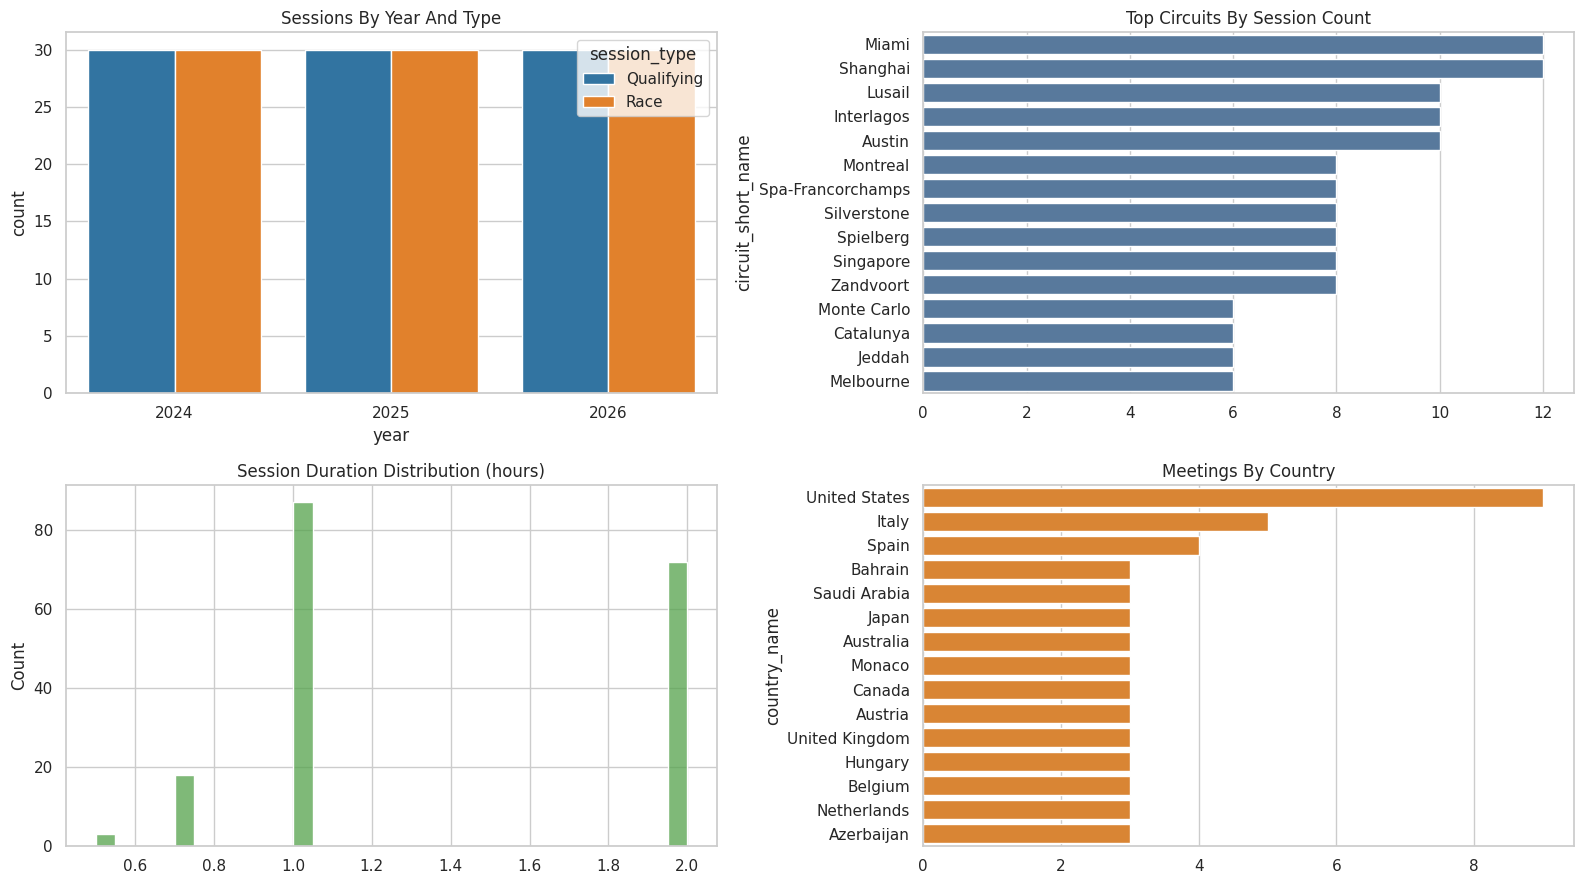

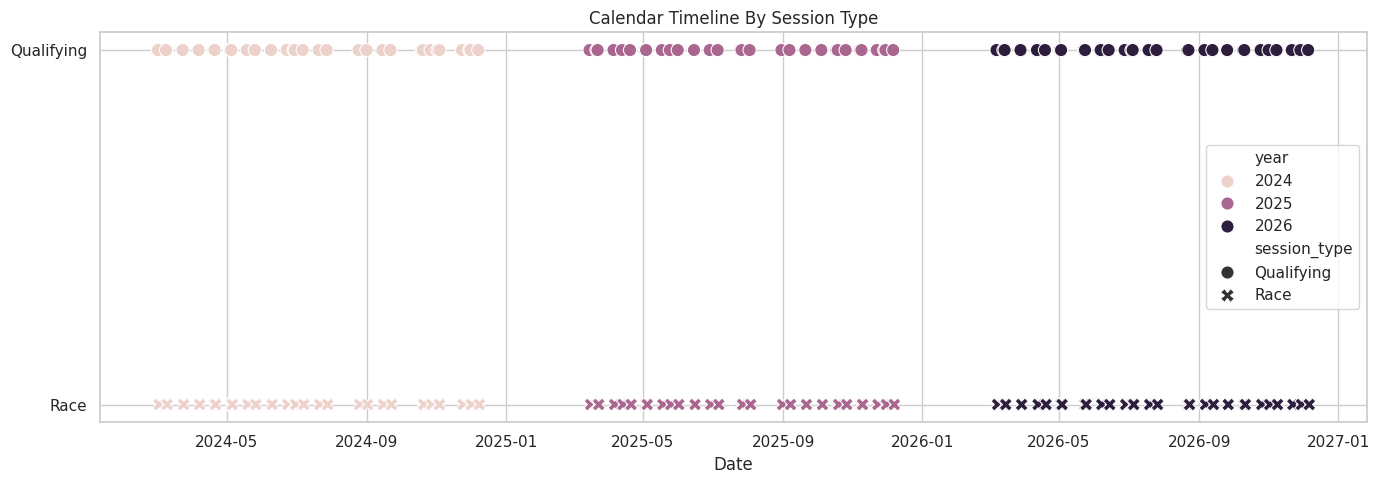

In [20]:

if not sessions.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    sns.countplot(data=sessions, x="year", hue="session_type", ax=axes[0, 0])
    axes[0, 0].set_title("Sessions By Year And Type")
    axes[0, 0].tick_params(axis="x", rotation=0)

    top_circuits = sessions["circuit_short_name"].value_counts().head(15)
    sns.barplot(y=top_circuits.index, x=top_circuits.values, ax=axes[0, 1], color="#4C78A8")
    axes[0, 1].set_title("Top Circuits By Session Count")

    if {"date_start", "date_end"}.issubset(sessions.columns):
        dur = (sessions["date_end"] - sessions["date_start"]).dt.total_seconds() / 3600
        sns.histplot(dur.dropna(), bins=30, ax=axes[1, 0], color="#54A24B")
        axes[1, 0].set_title("Session Duration Distribution (hours)")

    if not meetings.empty and "country_name" in meetings.columns:
        country_counts = meetings["country_name"].value_counts().head(15)
        sns.barplot(y=country_counts.index, x=country_counts.values, ax=axes[1, 1], color="#F58518")
        axes[1, 1].set_title("Meetings By Country")

    plt.tight_layout()
    plt.show()

    if {"date_start", "year", "session_type", "circuit_short_name"}.issubset(sessions.columns):
        fig, ax = plt.subplots(figsize=(14, 5))
        plot_df = sessions.dropna(subset=["date_start"]).sort_values("date_start")
        sns.scatterplot(data=plot_df, x="date_start", y="session_type", hue="year", style="session_type", s=90, ax=ax)
        ax.set_title("Calendar Timeline By Session Type")
        ax.set_xlabel("Date")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()


## 3. Drivers And Teams EDA

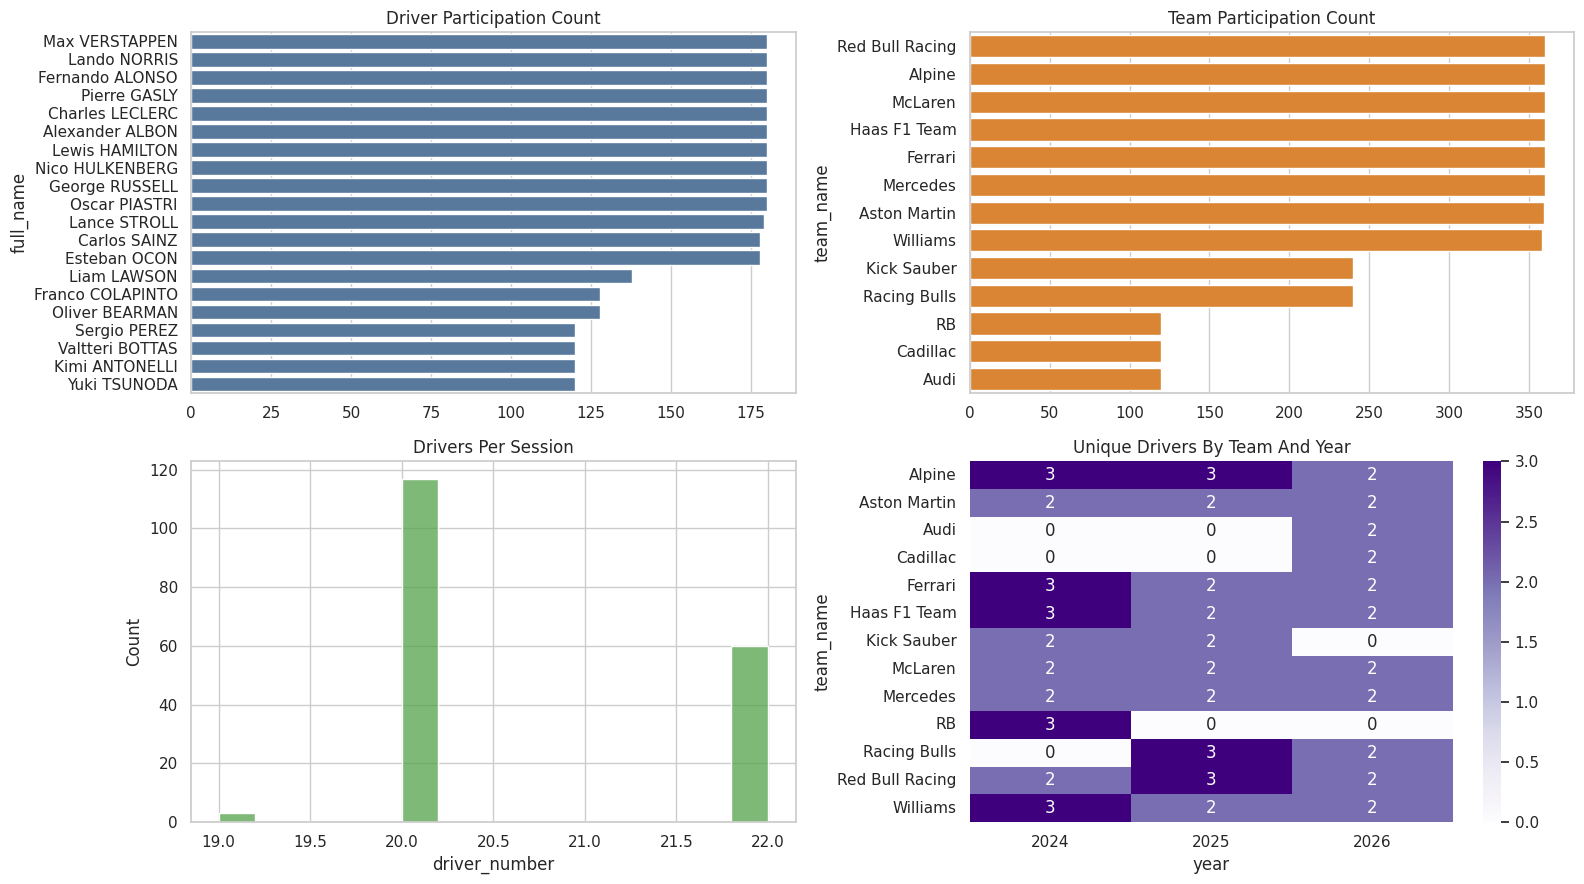

In [21]:

if not drivers.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))

    driver_counts = drivers["full_name"].value_counts().head(20) if "full_name" in drivers.columns else drivers["driver_number"].value_counts().head(20)
    sns.barplot(y=driver_counts.index, x=driver_counts.values, ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Driver Participation Count")

    if "team_name" in drivers.columns:
        team_counts = drivers["team_name"].value_counts().head(15)
        sns.barplot(y=team_counts.index, x=team_counts.values, ax=axes[0, 1], color="#F58518")
        axes[0, 1].set_title("Team Participation Count")

    per_session = drivers.groupby("session_key")["driver_number"].nunique()
    sns.histplot(per_session, bins=15, ax=axes[1, 0], color="#54A24B")
    axes[1, 0].set_title("Drivers Per Session")

    team_year = drivers.merge(session_meta[["session_key", "year"]], on="session_key", how="left")
    if {"team_name", "year"}.issubset(team_year.columns):
        pivot = team_year.pivot_table(index="team_name", columns="year", values="driver_number", aggfunc="nunique", fill_value=0)
        sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Purples", ax=axes[1, 1])
        axes[1, 1].set_title("Unique Drivers By Team And Year")

    plt.tight_layout()
    plt.show()


## 4. Results, Grid, And Race Outcome EDA

2026-06-15 03:26:01,737 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 03:26:01,740 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


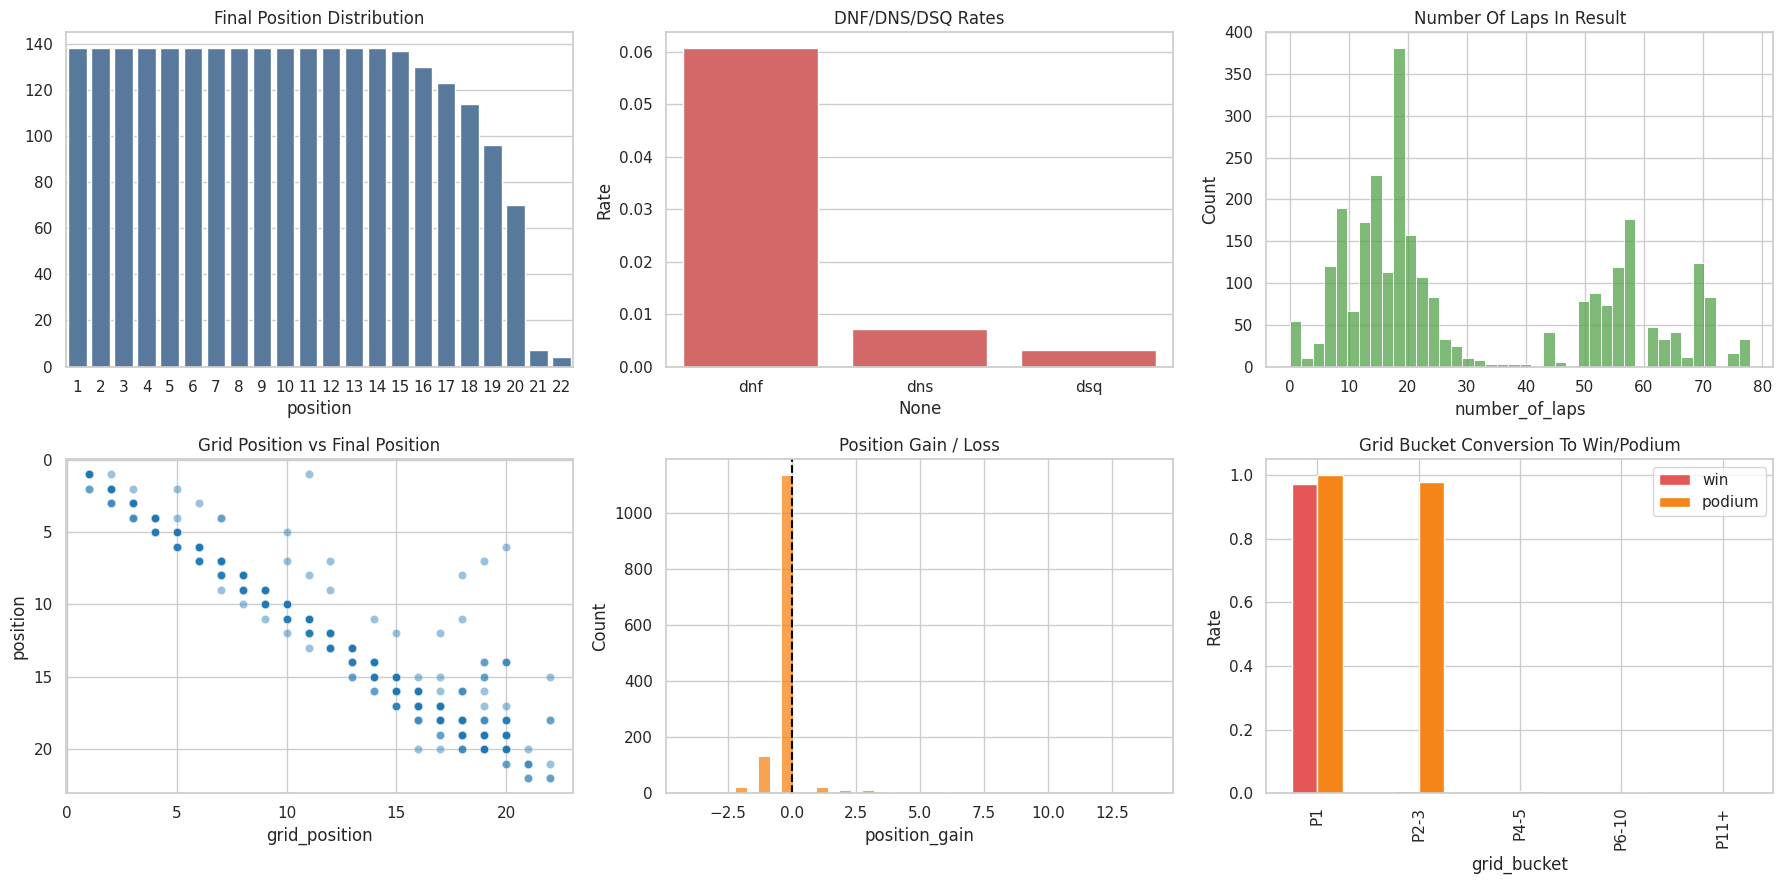

In [22]:

if not results.empty:
    res = results.copy()
    res["position"] = pd.to_numeric(res["position"], errors="coerce")
    if not grid.empty and {"session_key", "driver_number", "position"}.issubset(grid.columns):
        grid2 = grid[["session_key", "driver_number", "position"]].rename(columns={"position": "grid_position"})
        res = res.merge(grid2, on=["session_key", "driver_number"], how="left")
        res["grid_position"] = pd.to_numeric(res["grid_position"], errors="coerce")
        res["position_gain"] = res["grid_position"] - res["position"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    pos_counts = res["position"].dropna().astype(int).value_counts().sort_index()
    sns.barplot(x=pos_counts.index, y=pos_counts.values, ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Final Position Distribution")

    dnf_cols = [c for c in ["dnf", "dns", "dsq"] if c in res.columns]
    if dnf_cols:
        rates = res[dnf_cols].apply(lambda s: s.astype(str).str.lower().isin(["true", "1"]).mean()).sort_values(ascending=False)
        sns.barplot(x=rates.index, y=rates.values, ax=axes[0, 1], color="#E45756")
        axes[0, 1].set_title("DNF/DNS/DSQ Rates")
        axes[0, 1].set_ylabel("Rate")

    if "number_of_laps" in res.columns:
        sns.histplot(pd.to_numeric(res["number_of_laps"], errors="coerce").dropna(), bins=40, ax=axes[0, 2], color="#54A24B")
        axes[0, 2].set_title("Number Of Laps In Result")

    if "grid_position" in res.columns:
        sns.scatterplot(data=res, x="grid_position", y="position", alpha=0.45, ax=axes[1, 0])
        axes[1, 0].invert_yaxis()
        axes[1, 0].set_title("Grid Position vs Final Position")

        sns.histplot(res["position_gain"].dropna(), bins=40, ax=axes[1, 1], color="#F58518")
        axes[1, 1].axvline(0, color="black", ls="--")
        axes[1, 1].set_title("Position Gain / Loss")

        conv = res.assign(
            grid_bucket=pd.cut(res["grid_position"], [0, 1, 3, 5, 10, 25], labels=["P1", "P2-3", "P4-5", "P6-10", "P11+"]),
            win=(res["position"] == 1),
            podium=res["position"].between(1, 3),
        ).groupby("grid_bucket", observed=True)[["win", "podium"]].mean()
        conv.plot(kind="bar", ax=axes[1, 2], color=["#E45756", "#F58518"])
        axes[1, 2].set_title("Grid Bucket Conversion To Win/Podium")
        axes[1, 2].set_ylabel("Rate")

    plt.tight_layout()
    plt.show()


## 5. Laps, Sectors, And Pace EDA

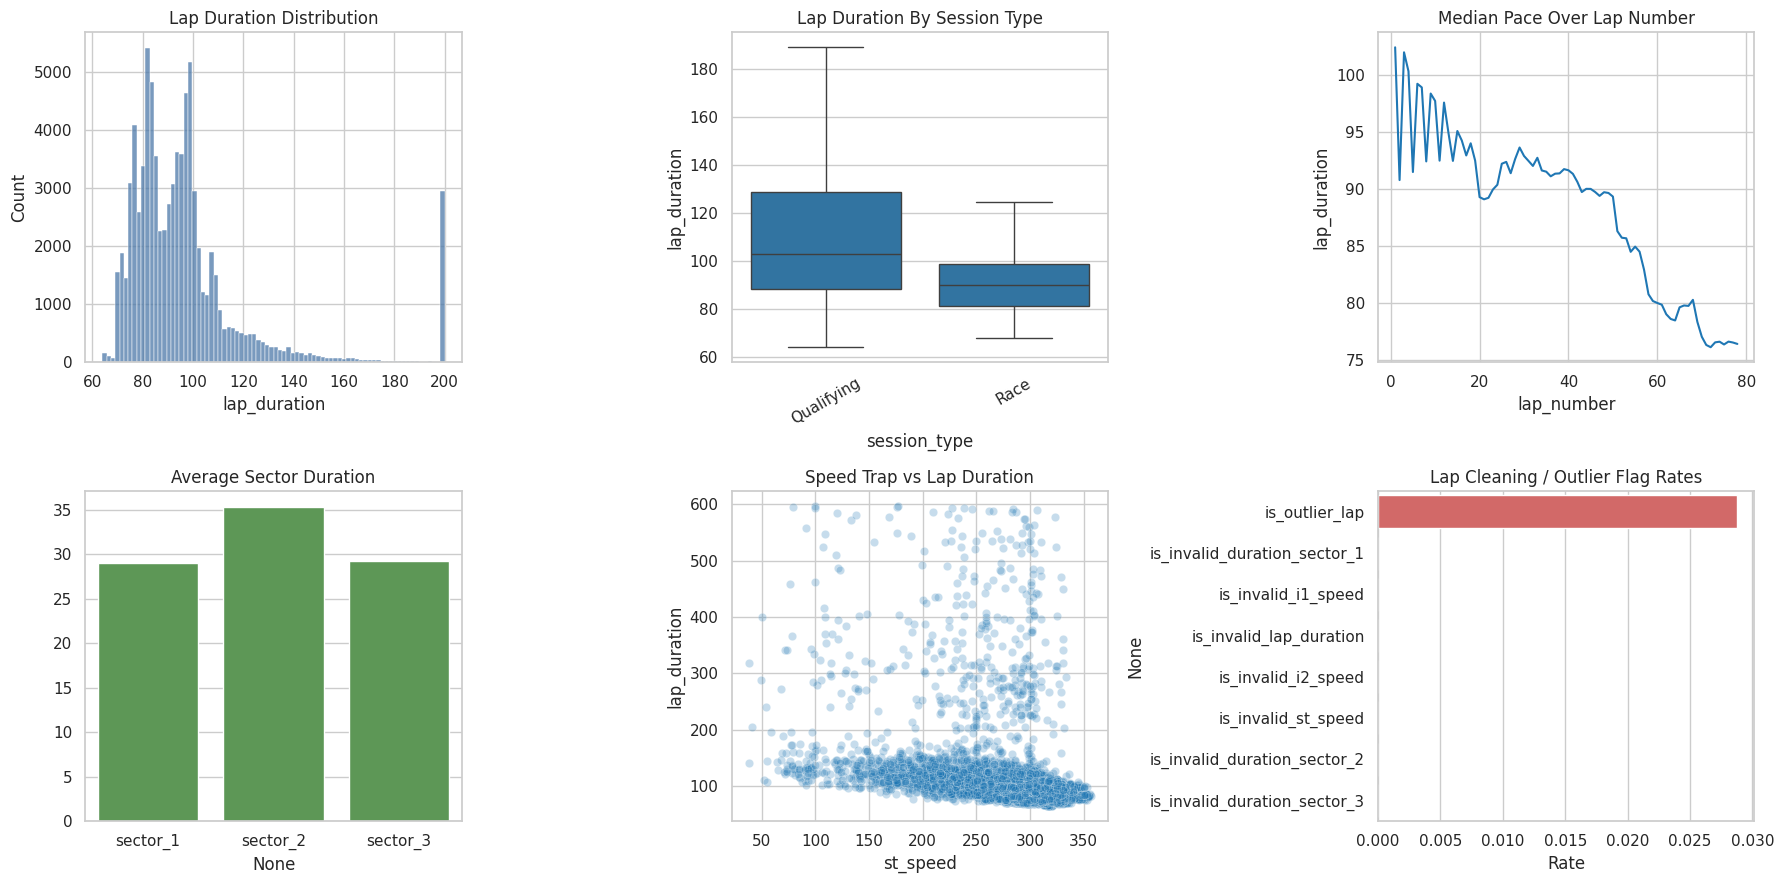

In [23]:

if not laps.empty:
    lap_meta = laps.merge(session_meta, on="session_key", how="left")
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    sns.histplot(lap_meta["lap_duration"].dropna().clip(upper=200), bins=80, ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Lap Duration Distribution")

    if "session_type" in lap_meta.columns:
        sns.boxplot(data=lap_meta, x="session_type", y="lap_duration", ax=axes[0, 1], showfliers=False)
        axes[0, 1].tick_params(axis="x", rotation=30)
        axes[0, 1].set_title("Lap Duration By Session Type")

    pace_by_lap = lap_meta.groupby("lap_number")["lap_duration"].median().reset_index()
    sns.lineplot(data=pace_by_lap, x="lap_number", y="lap_duration", ax=axes[0, 2])
    axes[0, 2].set_title("Median Pace Over Lap Number")

    sector_cols = [c for c in ["duration_sector_1", "duration_sector_2", "duration_sector_3"] if c in laps.columns]
    if sector_cols:
        sector_mean = laps[sector_cols].mean().rename(index=lambda x: x.replace("duration_", ""))
        sns.barplot(x=sector_mean.index, y=sector_mean.values, ax=axes[1, 0], color="#54A24B")
        axes[1, 0].set_title("Average Sector Duration")

    speed_cols = [c for c in ["i1_speed", "i2_speed", "st_speed"] if c in laps.columns]
    if speed_cols:
        sns.scatterplot(data=lap_meta.sample(min(10000, len(lap_meta)), random_state=42), x="st_speed", y="lap_duration", alpha=0.25, ax=axes[1, 1])
        axes[1, 1].set_title("Speed Trap vs Lap Duration")

    flag_cols = [c for c in laps.columns if c.startswith("is_invalid_") or c in ["is_outlier_lap"]]
    if flag_cols:
        rates = laps[flag_cols].apply(lambda s: s.astype(bool).mean()).sort_values(ascending=False).head(10)
        sns.barplot(y=rates.index, x=rates.values, ax=axes[1, 2], color="#E45756")
        axes[1, 2].set_title("Lap Cleaning / Outlier Flag Rates")
        axes[1, 2].set_xlabel("Rate")

    plt.tight_layout()
    plt.show()


## 6. Stints And Tyre Strategy EDA

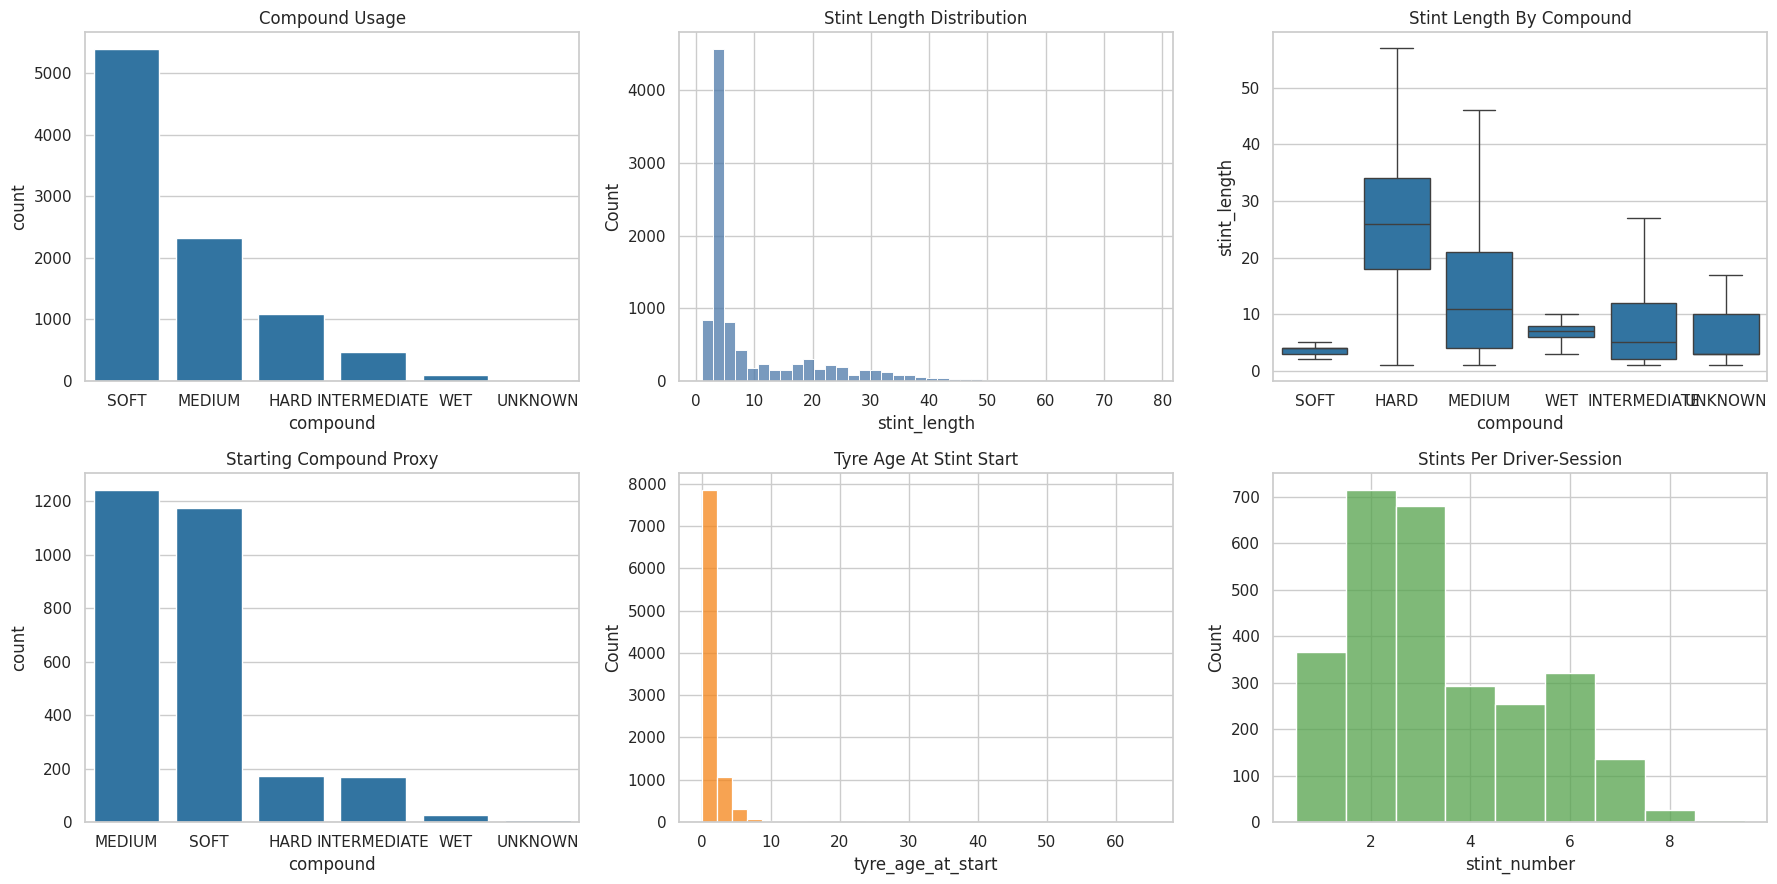

In [24]:

if not stints.empty:
    st = stints.copy()
    st["stint_length"] = pd.to_numeric(st["lap_end"], errors="coerce") - pd.to_numeric(st["lap_start"], errors="coerce") + 1
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    sns.countplot(data=st, x="compound", order=st["compound"].value_counts().index, ax=axes[0, 0])
    axes[0, 0].set_title("Compound Usage")

    sns.histplot(st["stint_length"].dropna(), bins=40, ax=axes[0, 1], color="#4C78A8")
    axes[0, 1].set_title("Stint Length Distribution")

    sns.boxplot(data=st, x="compound", y="stint_length", ax=axes[0, 2], showfliers=False)
    axes[0, 2].set_title("Stint Length By Compound")

    first_stint = st.sort_values(["session_key", "driver_number", "stint_number"]).groupby(["session_key", "driver_number"]).first().reset_index()
    sns.countplot(data=first_stint, x="compound", order=first_stint["compound"].value_counts().index, ax=axes[1, 0])
    axes[1, 0].set_title("Starting Compound Proxy")

    if "tyre_age_at_start" in st.columns:
        sns.histplot(pd.to_numeric(st["tyre_age_at_start"], errors="coerce").dropna(), bins=30, ax=axes[1, 1], color="#F58518")
        axes[1, 1].set_title("Tyre Age At Stint Start")

    stint_count = st.groupby(["session_key", "driver_number"])["stint_number"].nunique()
    sns.histplot(stint_count, discrete=True, ax=axes[1, 2], color="#54A24B")
    axes[1, 2].set_title("Stints Per Driver-Session")

    plt.tight_layout()
    plt.show()


## 7. Weather EDA

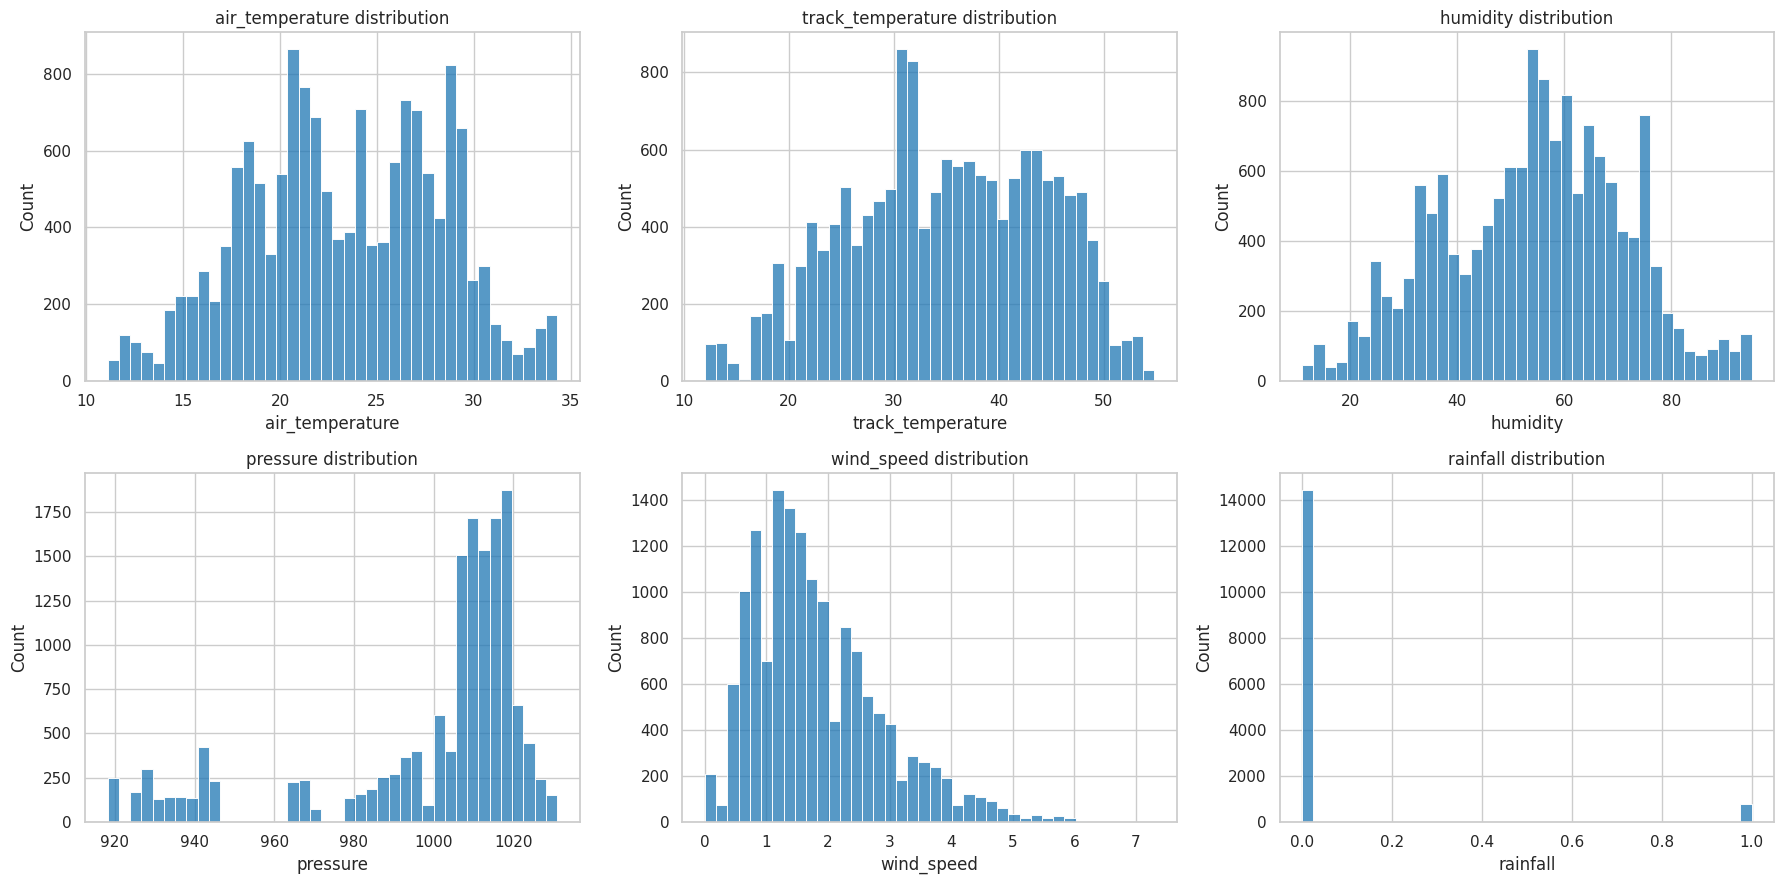

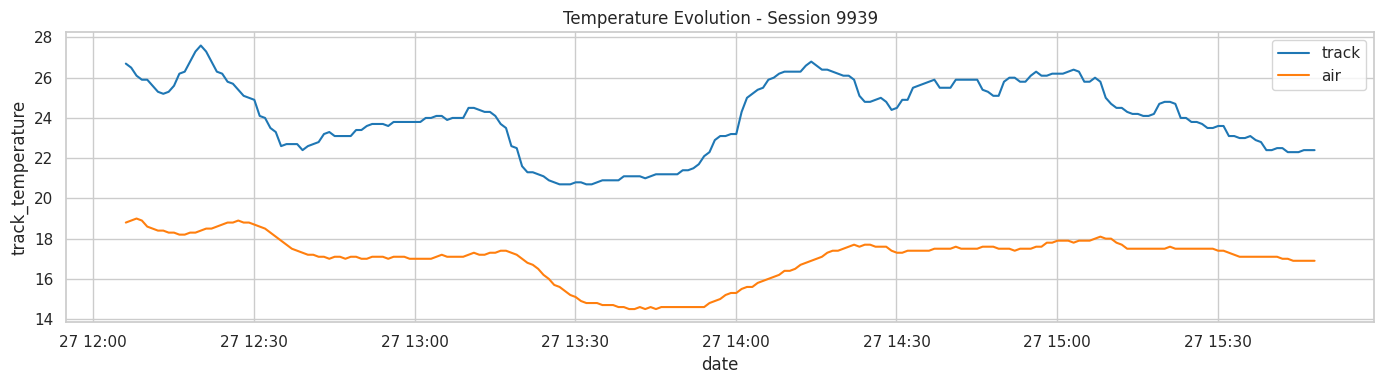

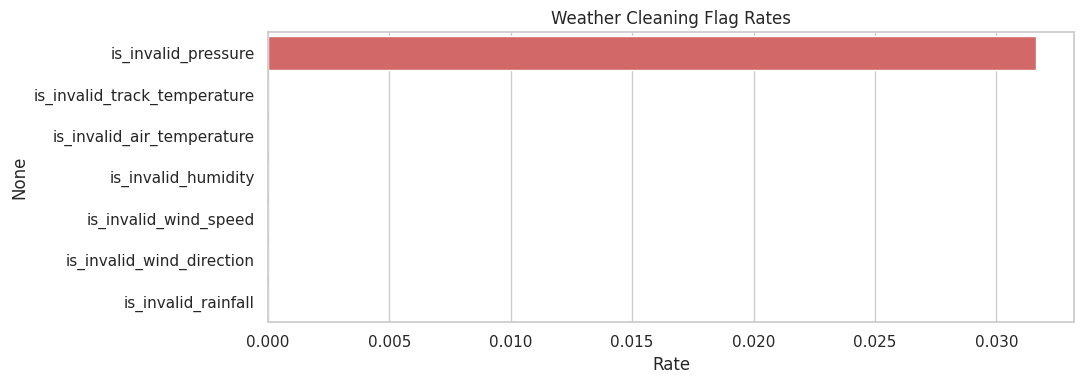

In [25]:

if not weather.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    cols = ["air_temperature", "track_temperature", "humidity", "pressure", "wind_speed", "rainfall"]
    for ax, col in zip(axes.ravel(), cols):
        if col in weather.columns:
            sns.histplot(pd.to_numeric(weather[col], errors="coerce").dropna(), bins=40, ax=ax)
            ax.set_title(f"{col} distribution")
    plt.tight_layout()
    plt.show()

    if {"session_key", "date", "track_temperature"}.issubset(weather.columns):
        sample_session = weather["session_key"].value_counts().index[0]
        w = weather[weather["session_key"] == sample_session].sort_values("date")
        fig, ax = plt.subplots(figsize=(14, 4))
        sns.lineplot(data=w, x="date", y="track_temperature", ax=ax, label="track")
        if "air_temperature" in w.columns:
            sns.lineplot(data=w, x="date", y="air_temperature", ax=ax, label="air")
        ax.set_title(f"Temperature Evolution - Session {sample_session}")
        plt.tight_layout()
        plt.show()

    invalid_cols = [c for c in weather.columns if c.startswith("is_invalid_")]
    if invalid_cols:
        rates = weather[invalid_cols].apply(lambda s: s.astype(bool).mean()).sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(11, 4))
        sns.barplot(y=rates.index, x=rates.values, ax=ax, color="#E45756")
        ax.set_title("Weather Cleaning Flag Rates")
        ax.set_xlabel("Rate")
        plt.tight_layout()
        plt.show()


## 8. Intervals And Position EDA

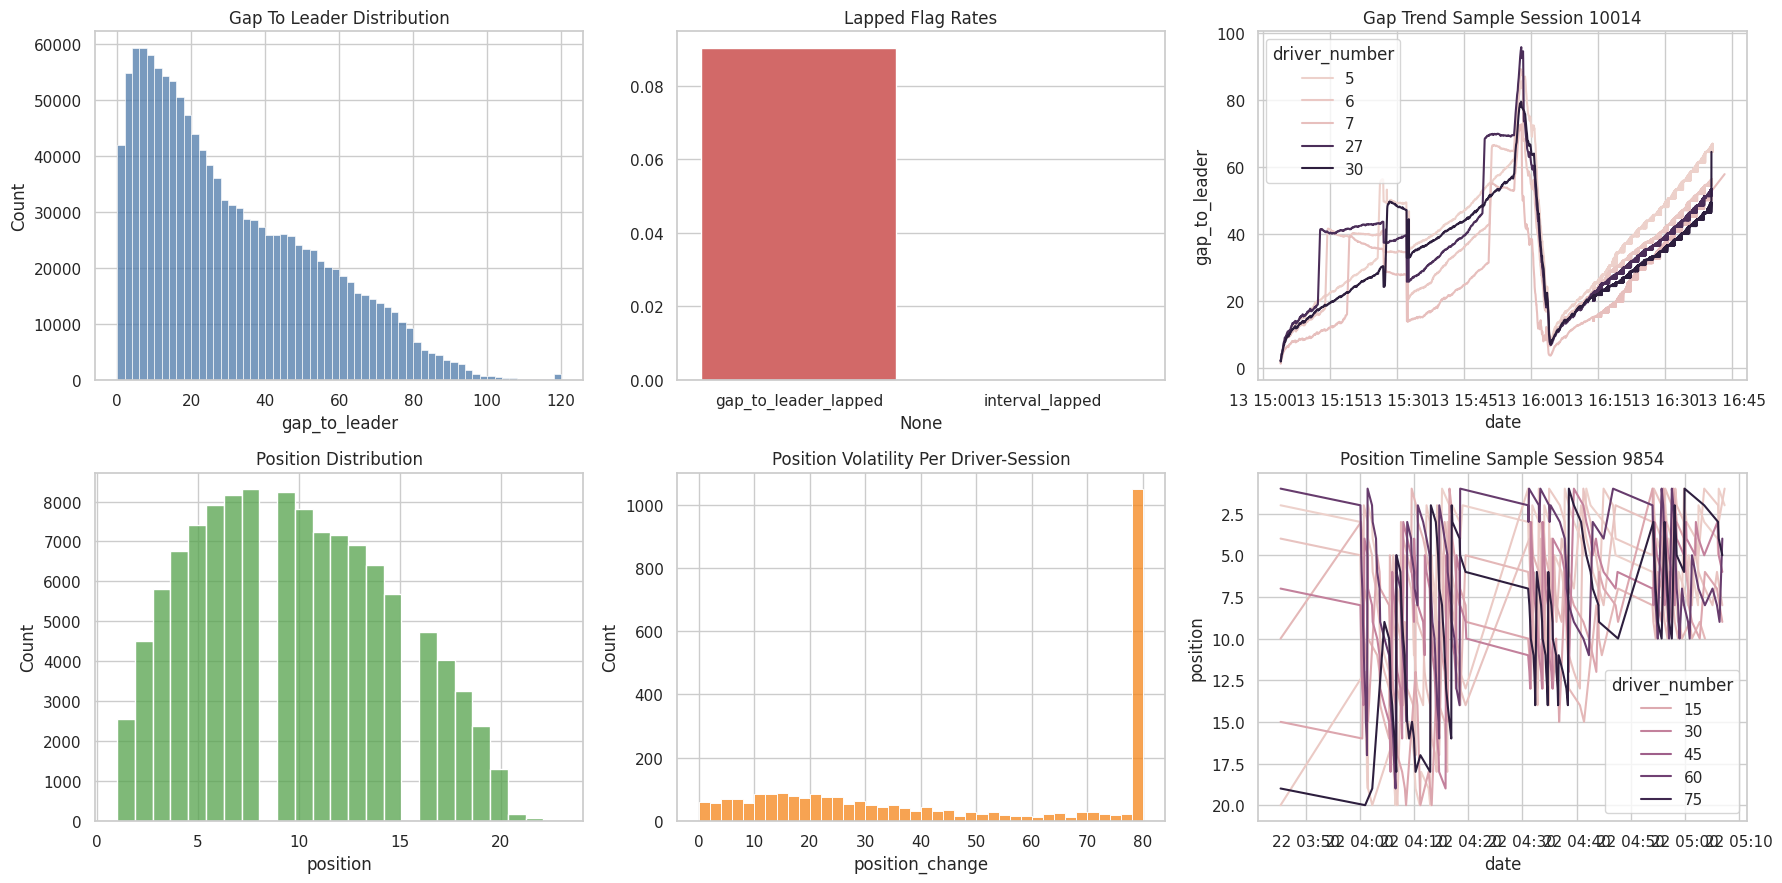

In [26]:

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

if not intervals.empty:
    if "gap_to_leader" in intervals.columns:
        sns.histplot(pd.to_numeric(intervals["gap_to_leader"], errors="coerce").dropna().clip(upper=120), bins=60, ax=axes[0, 0], color="#4C78A8")
        axes[0, 0].set_title("Gap To Leader Distribution")
    lapped_cols = [c for c in ["gap_to_leader_lapped", "interval_lapped"] if c in intervals.columns]
    if lapped_cols:
        rates = intervals[lapped_cols].apply(lambda s: s.astype(bool).mean())
        sns.barplot(x=rates.index, y=rates.values, ax=axes[0, 1], color="#E45756")
        axes[0, 1].set_title("Lapped Flag Rates")
    if {"session_key", "driver_number", "date", "gap_to_leader"}.issubset(intervals.columns):
        sample = intervals.dropna(subset=["gap_to_leader"]).sort_values("date")
        sk = sample["session_key"].value_counts().index[0]
        tmp = sample[sample["session_key"] == sk]
        top_drivers = tmp["driver_number"].value_counts().head(5).index
        sns.lineplot(data=tmp[tmp["driver_number"].isin(top_drivers)], x="date", y="gap_to_leader", hue="driver_number", ax=axes[0, 2])
        axes[0, 2].set_title(f"Gap Trend Sample Session {sk}")

if not position.empty:
    sns.histplot(pd.to_numeric(position["position"], errors="coerce").dropna(), bins=25, ax=axes[1, 0], color="#54A24B")
    axes[1, 0].set_title("Position Distribution")
    pos_sorted = position.sort_values(["session_key", "driver_number", "date"]).copy()
    pos_sorted["position_change"] = pos_sorted.groupby(["session_key", "driver_number"])["position"].diff().abs()
    volatility = pos_sorted.groupby(["session_key", "driver_number"])["position_change"].sum().dropna()
    sns.histplot(volatility.clip(upper=80), bins=40, ax=axes[1, 1], color="#F58518")
    axes[1, 1].set_title("Position Volatility Per Driver-Session")
    sk = position["session_key"].value_counts().index[0]
    tmp = position[position["session_key"] == sk].sort_values("date")
    top_drivers = tmp["driver_number"].value_counts().head(8).index
    sns.lineplot(data=tmp[tmp["driver_number"].isin(top_drivers)], x="date", y="position", hue="driver_number", ax=axes[1, 2])
    axes[1, 2].invert_yaxis()
    axes[1, 2].set_title(f"Position Timeline Sample Session {sk}")

plt.tight_layout()
plt.show()


## 9. Race Control, Pit, Overtakes, And Team Radio EDA

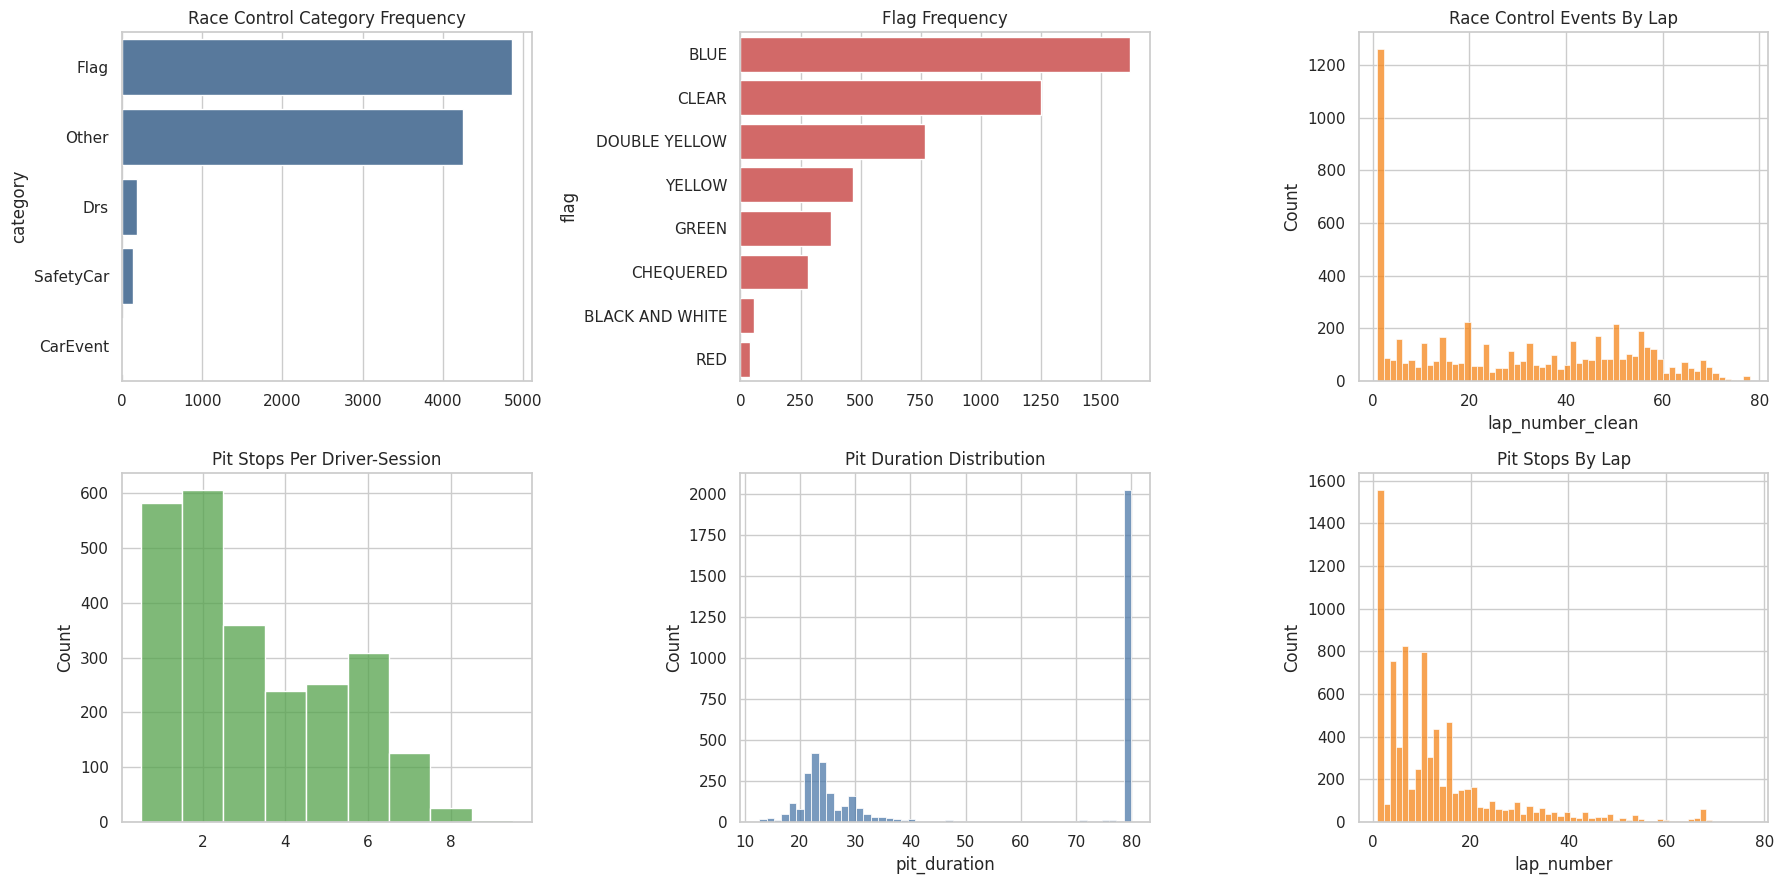

In [27]:

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

if not race_control.empty:
    cat = race_control["category"].value_counts().head(12)
    sns.barplot(y=cat.index, x=cat.values, ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Race Control Category Frequency")
    if "flag" in race_control.columns:
        flag = race_control["flag"].replace("", np.nan).dropna().value_counts().head(10)
        sns.barplot(y=flag.index, x=flag.values, ax=axes[0, 1], color="#E45756")
        axes[0, 1].set_title("Flag Frequency")
    if "lap_number_clean" in race_control.columns:
        sns.histplot(pd.to_numeric(race_control["lap_number_clean"], errors="coerce").dropna(), bins=60, ax=axes[0, 2], color="#F58518")
        axes[0, 2].set_title("Race Control Events By Lap")

if not pit.empty:
    pit_count = pit.groupby(["session_key", "driver_number"]).size()
    sns.histplot(pit_count, discrete=True, ax=axes[1, 0], color="#54A24B")
    axes[1, 0].set_title("Pit Stops Per Driver-Session")
    if "pit_duration" in pit.columns:
        sns.histplot(pd.to_numeric(pit["pit_duration"], errors="coerce").dropna().clip(upper=80), bins=50, ax=axes[1, 1], color="#4C78A8")
        axes[1, 1].set_title("Pit Duration Distribution")
    if "lap_number" in pit.columns:
        sns.histplot(pd.to_numeric(pit["lap_number"], errors="coerce").dropna(), bins=60, ax=axes[1, 2], color="#F58518")
        axes[1, 2].set_title("Pit Stops By Lap")

plt.tight_layout()
plt.show()


2026-06-15 03:26:07,696 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 03:26:07,699 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


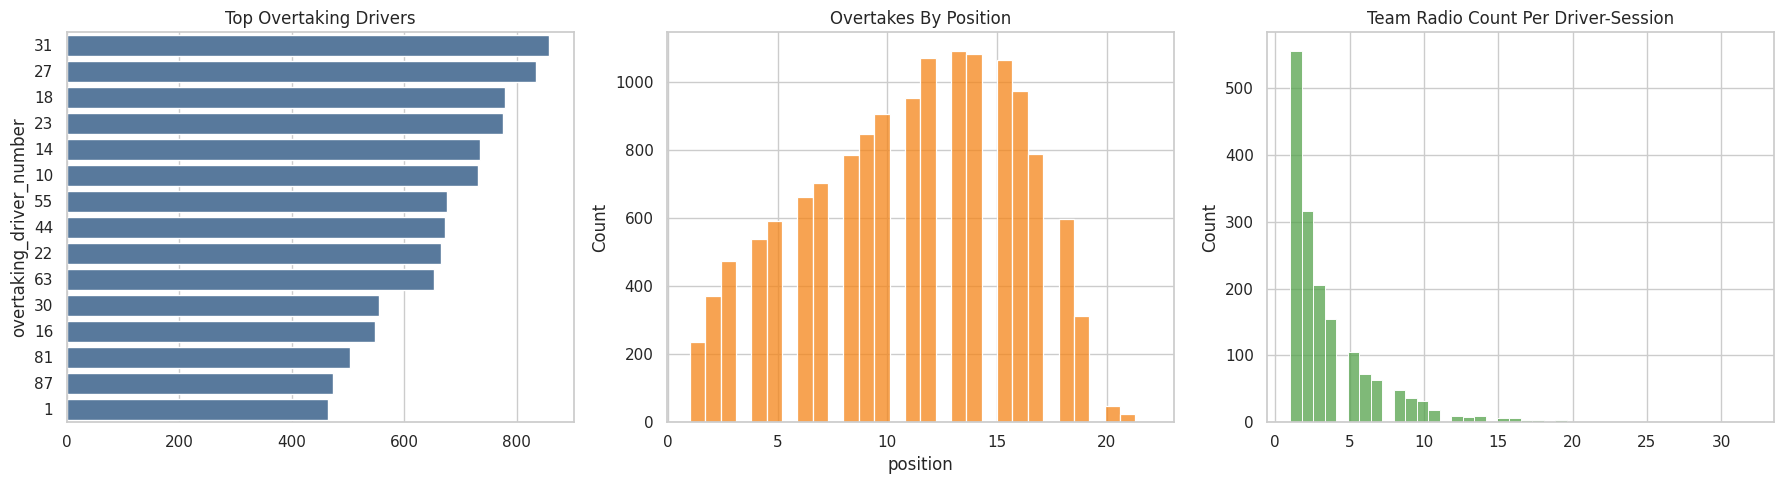

In [28]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if not overtakes.empty:
    overtake_cols = set(overtakes.columns)
    driver_col = "overtaking_driver_number" if "overtaking_driver_number" in overtake_cols else "driver_number"
    if driver_col in overtakes.columns:
        top = overtakes[driver_col].value_counts().head(15)
        sns.barplot(y=top.index.astype(str), x=top.values, ax=axes[0], color="#4C78A8")
        axes[0].set_title("Top Overtaking Drivers")
    if "position" in overtakes.columns:
        sns.histplot(pd.to_numeric(overtakes["position"], errors="coerce").dropna(), bins=30, ax=axes[1], color="#F58518")
        axes[1].set_title("Overtakes By Position")

if not team_radio.empty:
    radio_count = team_radio.groupby(["session_key", "driver_number"]).size()
    sns.histplot(radio_count, bins=40, ax=axes[2], color="#54A24B")
    axes[2].set_title("Team Radio Count Per Driver-Session")

plt.tight_layout()
plt.show()


## 10. Telemetry And Location Sampling EDA

In [29]:

def read_parquet_sample(name, columns=None, max_rows=500_000, session_key=None):
    path = CLEAN_DIR / f"{name}.parquet"
    if not path.exists():
        return pd.DataFrame()
    pf = pq.ParquetFile(path)
    chunks = []
    total = 0
    for batch in pf.iter_batches(batch_size=200_000, columns=columns):
        chunk = batch.to_pandas()
        if session_key is not None and "session_key" in chunk.columns:
            chunk = chunk[chunk["session_key"] == session_key]
        if chunk.empty:
            continue
        chunks.append(chunk)
        total += len(chunk)
        if total >= max_rows:
            break
    return pd.concat(chunks, ignore_index=True).head(max_rows) if chunks else pd.DataFrame()

tele_cols = ["Date", "session_key", "driver_number", "lap_number", "Speed", "RPM", "Throttle", "Brake", "DRS", "nGear"]
tele = read_parquet_sample("car_data", columns=tele_cols, max_rows=500_000)
print(f"telemetry sample: {tele.shape}")
display(tele.head())


telemetry sample: (500000, 10)


,Date,session_key,driver_number,lap_number,Speed,RPM,Throttle,Brake,DRS,nGear
0,2024-03-01 16:06:46.101000+00:00,9468,1,1.0,11.0,3489.325011,0.0,0.0,8.0,1.0
1,2024-03-01 16:06:46.116000+00:00,9468,1,1.0,11.0,3486.700000,0.0,0.0,8.0,1.0
2,2024-03-01 16:06:46.120000+00:00,9468,1,1.0,11.0,3486.000000,0.0,0.0,8.0,1.0
3,2024-03-01 16:06:46.400000+00:00,9468,1,1.0,10.0,3543.000000,0.0,0.0,8.0,1.0
4,2024-03-01 16:06:46.575000+00:00,9468,1,1.0,10.0,3619.125028,0.0,0.0,8.0,1.0


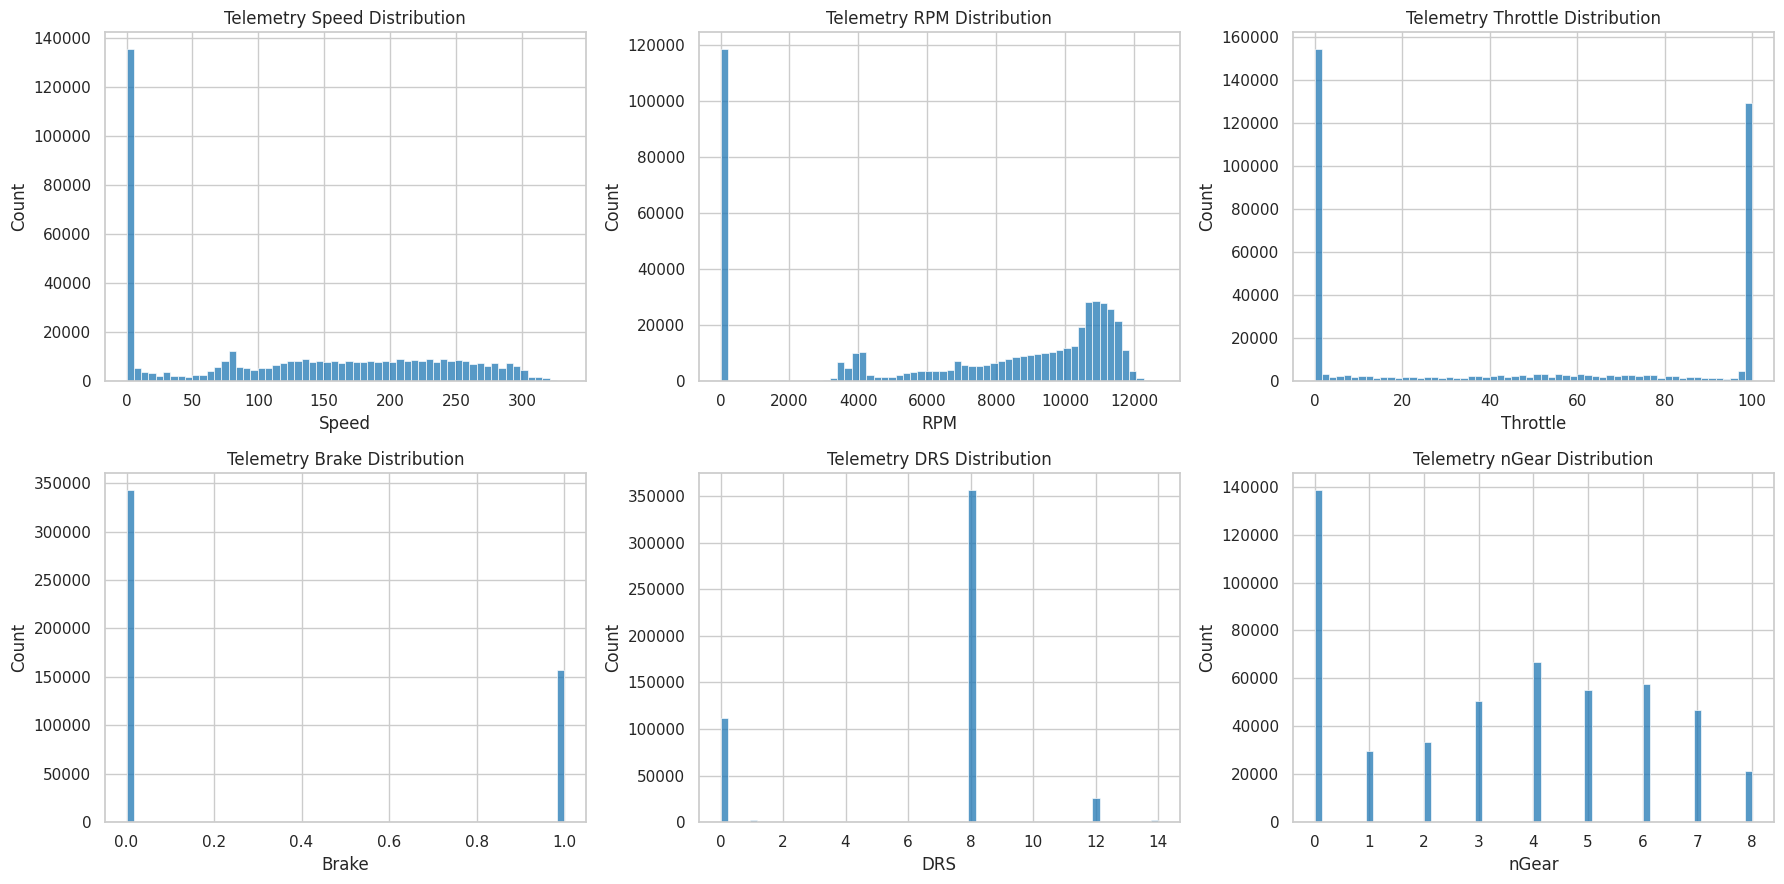

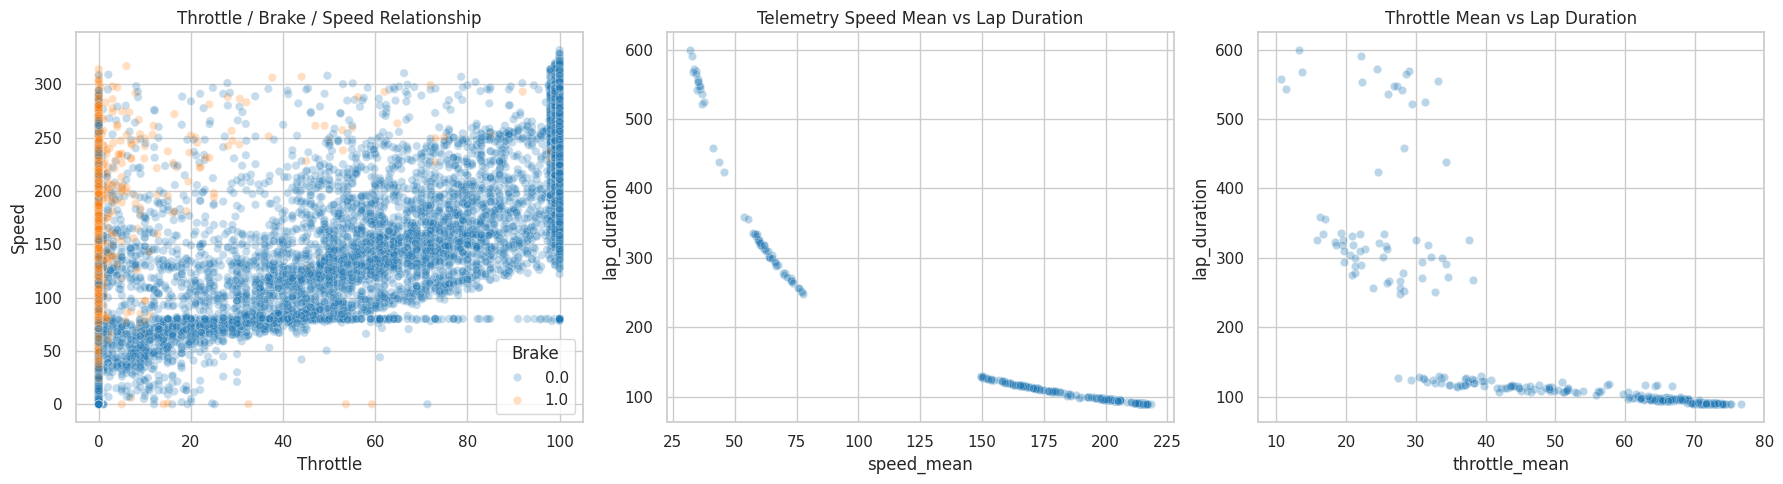

In [30]:

if not tele.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    for ax, col in zip(axes.ravel(), ["Speed", "RPM", "Throttle", "Brake", "DRS", "nGear"]):
        if col in tele.columns:
            sns.histplot(pd.to_numeric(tele[col], errors="coerce").dropna(), bins=60, ax=ax)
            ax.set_title(f"Telemetry {col} Distribution")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(data=tele.sample(min(20000, len(tele)), random_state=42), x="Throttle", y="Speed", hue="Brake", alpha=0.25, ax=axes[0])
    axes[0].set_title("Throttle / Brake / Speed Relationship")
    if {"session_key", "driver_number", "lap_number", "Speed"}.issubset(tele.columns):
        lap_tele = tele.groupby(["session_key", "driver_number", "lap_number"]).agg(
            speed_mean=("Speed", "mean"),
            speed_max=("Speed", "max"),
            throttle_mean=("Throttle", "mean"),
            brake_mean=("Brake", "mean"),
        ).reset_index()
        lap_join = lap_tele.merge(laps[["session_key", "driver_number", "lap_number", "lap_duration"]], on=["session_key", "driver_number", "lap_number"], how="inner")
        sns.scatterplot(data=lap_join.sample(min(20000, len(lap_join)), random_state=42), x="speed_mean", y="lap_duration", alpha=0.3, ax=axes[1])
        axes[1].set_title("Telemetry Speed Mean vs Lap Duration")
        sns.scatterplot(data=lap_join.sample(min(20000, len(lap_join)), random_state=42), x="throttle_mean", y="lap_duration", alpha=0.3, ax=axes[2])
        axes[2].set_title("Throttle Mean vs Lap Duration")
    plt.tight_layout()
    plt.show()


location sample: (345720, 7), session=11299


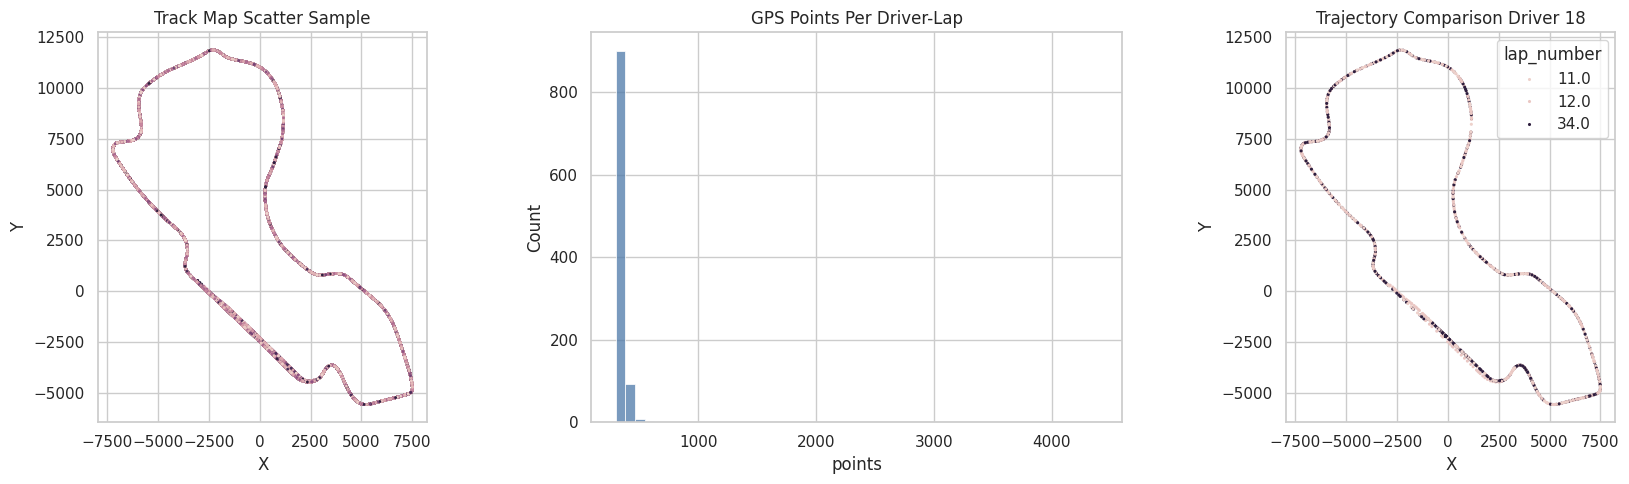

In [31]:

sample_session = None
if not laps.empty:
    sample_session = laps["session_key"].value_counts().index[0]

loc_cols = ["Date", "session_key", "driver_number", "lap_number", "X", "Y", "Z"]
loc = read_parquet_sample("location", columns=loc_cols, max_rows=400_000, session_key=sample_session)
print(f"location sample: {loc.shape}, session={sample_session}")

if not loc.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    loc_sample = loc.sample(min(100000, len(loc)), random_state=42)
    sns.scatterplot(data=loc_sample, x="X", y="Y", hue="driver_number", s=4, linewidth=0, legend=False, ax=axes[0])
    axes[0].set_title("Track Map Scatter Sample")
    axes[0].set_aspect("equal", adjustable="box")

    if "lap_number" in loc.columns:
        lap_counts = loc.groupby(["driver_number", "lap_number"]).size().reset_index(name="points")
        sns.histplot(lap_counts["points"], bins=50, ax=axes[1], color="#4C78A8")
        axes[1].set_title("GPS Points Per Driver-Lap")

        driver = loc["driver_number"].value_counts().index[0]
        sample_laps = loc[loc["driver_number"] == driver]["lap_number"].dropna().value_counts().head(3).index
        tmp = loc[(loc["driver_number"] == driver) & (loc["lap_number"].isin(sample_laps))]
        sns.scatterplot(data=tmp.sample(min(50000, len(tmp)), random_state=42), x="X", y="Y", hue="lap_number", s=5, linewidth=0, ax=axes[2])
        axes[2].set_title(f"Trajectory Comparison Driver {driver}")
        axes[2].set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()


## 11. Cross-Endpoint Feature Insight

2026-06-15 03:26:14,728 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 03:26:14,733 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 03:26:14,795 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 03:26:14,801 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


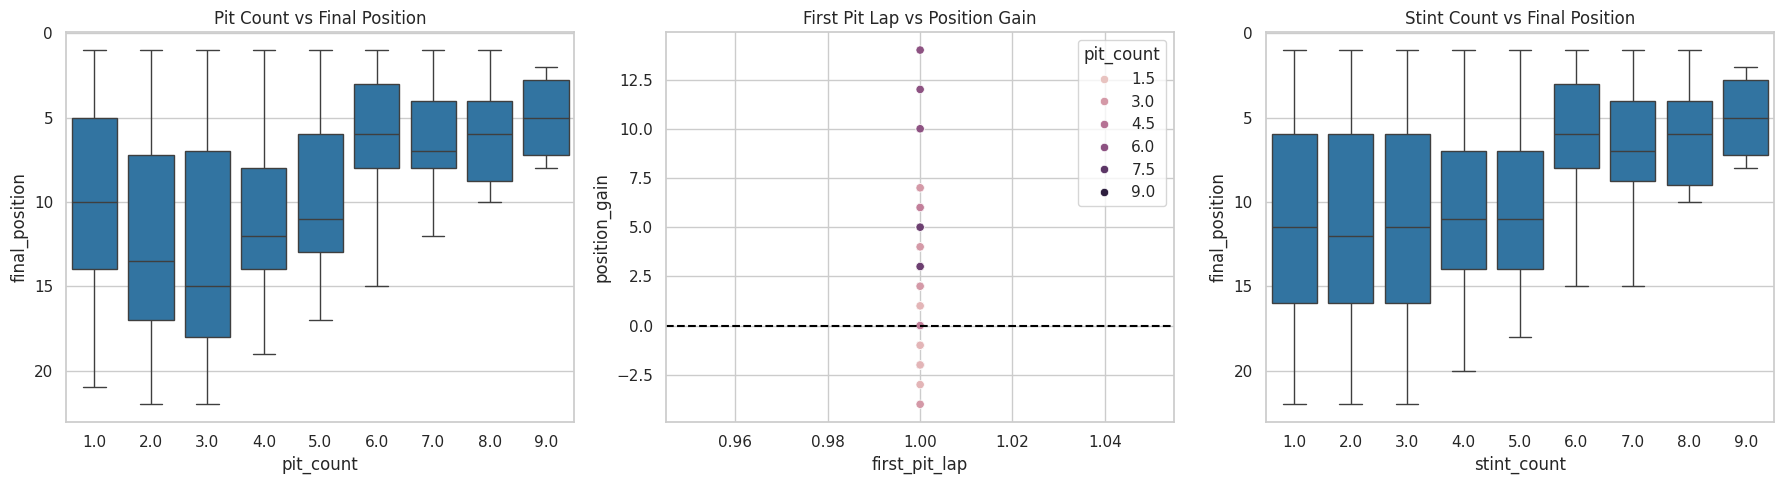

In [32]:

# Pit strategy + grid/result relationship
if not results.empty:
    analysis = results[["session_key", "driver_number", "position"]].copy()
    analysis["final_position"] = pd.to_numeric(analysis["position"], errors="coerce")
    if not grid.empty:
        analysis = analysis.merge(
            grid[["session_key", "driver_number", "position"]].rename(columns={"position": "grid_position"}),
            on=["session_key", "driver_number"], how="left"
        )
        analysis["grid_position"] = pd.to_numeric(analysis["grid_position"], errors="coerce")
        analysis["position_gain"] = analysis["grid_position"] - analysis["final_position"]
    if not pit.empty:
        pit_features = pit.groupby(["session_key", "driver_number"]).agg(
            pit_count=("lap_number", "count"),
            first_pit_lap=("lap_number", "min"),
            avg_pit_duration=("pit_duration", "mean"),
        ).reset_index()
        analysis = analysis.merge(pit_features, on=["session_key", "driver_number"], how="left")
    if not stints.empty:
        stint_features = stints.groupby(["session_key", "driver_number"]).agg(stint_count=("stint_number", "nunique")).reset_index()
        analysis = analysis.merge(stint_features, on=["session_key", "driver_number"], how="left")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    if "pit_count" in analysis.columns:
        sns.boxplot(data=analysis, x="pit_count", y="final_position", ax=axes[0], showfliers=False)
        axes[0].invert_yaxis()
        axes[0].set_title("Pit Count vs Final Position")
    if "first_pit_lap" in analysis.columns and "position_gain" in analysis.columns:
        sns.scatterplot(data=analysis, x="first_pit_lap", y="position_gain", hue="pit_count", ax=axes[1])
        axes[1].axhline(0, color="black", ls="--")
        axes[1].set_title("First Pit Lap vs Position Gain")
    if "stint_count" in analysis.columns:
        sns.boxplot(data=analysis, x="stint_count", y="final_position", ax=axes[2], showfliers=False)
        axes[2].invert_yaxis()
        axes[2].set_title("Stint Count vs Final Position")
    plt.tight_layout()
    plt.show()


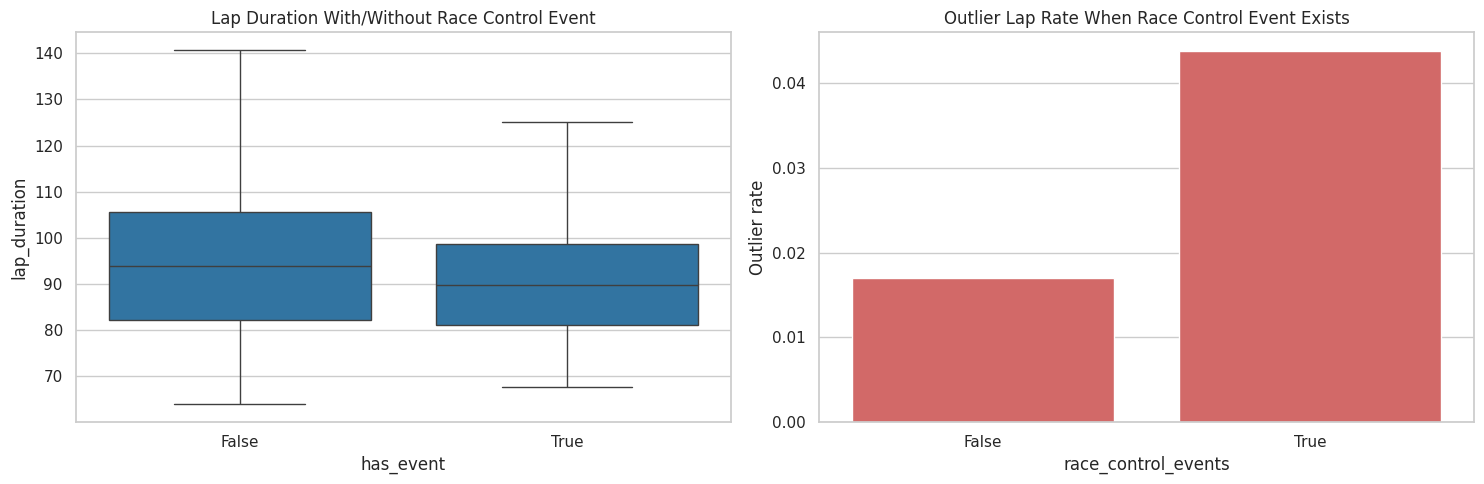

In [33]:

# Race-control events and lap outliers
if not race_control.empty and not laps.empty:
    rc_laps = race_control.dropna(subset=["lap_number_clean"]).copy()
    if not rc_laps.empty:
        events_by_lap = rc_laps.groupby(["session_key", "lap_number_clean"]).size().reset_index(name="race_control_events")
        events_by_lap = events_by_lap.rename(columns={"lap_number_clean": "lap_number"})
        lap_rc = laps.merge(events_by_lap, on=["session_key", "lap_number"], how="left")
        lap_rc["race_control_events"] = lap_rc["race_control_events"].fillna(0)
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        sns.boxplot(data=lap_rc.assign(has_event=lap_rc["race_control_events"] > 0), x="has_event", y="lap_duration", ax=axes[0], showfliers=False)
        axes[0].set_title("Lap Duration With/Without Race Control Event")
        if "is_outlier_lap" in lap_rc.columns:
            rates = lap_rc.groupby(lap_rc["race_control_events"] > 0)["is_outlier_lap"].mean()
            sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[1], color="#E45756")
            axes[1].set_title("Outlier Lap Rate When Race Control Event Exists")
            axes[1].set_ylabel("Outlier rate")
        plt.tight_layout()
        plt.show()


2026-06-15 03:26:15,498 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 03:26:15,503 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


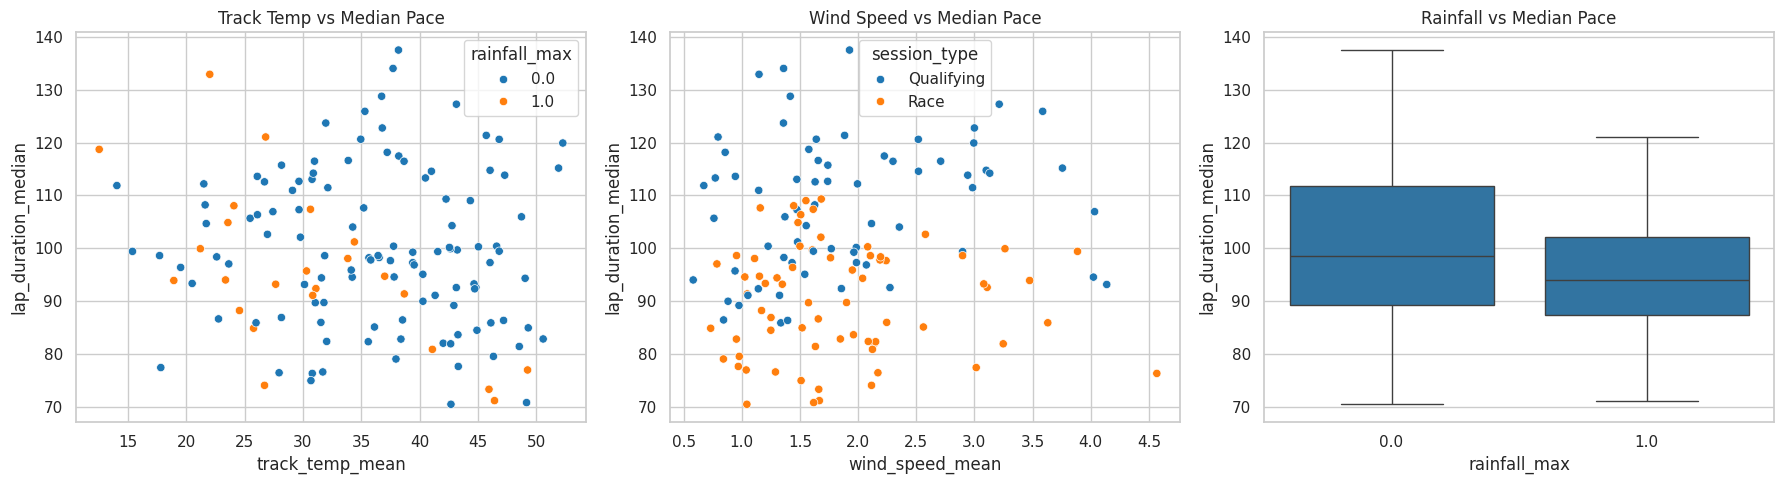

In [34]:

# Weather and pace: session-level relationship
if not weather.empty and not laps.empty:
    weather_summary = weather.groupby("session_key").agg(
        track_temp_mean=("track_temperature", "mean"),
        air_temp_mean=("air_temperature", "mean"),
        rainfall_max=("rainfall", "max"),
        wind_speed_mean=("wind_speed", "mean"),
    ).reset_index()
    pace_summary = laps.groupby("session_key").agg(
        lap_duration_median=("lap_duration", "median"),
        outlier_rate=("is_outlier_lap", "mean") if "is_outlier_lap" in laps.columns else ("lap_duration", "size"),
    ).reset_index()
    wp = pace_summary.merge(weather_summary, on="session_key", how="inner").merge(session_meta, on="session_key", how="left")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(data=wp, x="track_temp_mean", y="lap_duration_median", hue="rainfall_max", ax=axes[0])
    axes[0].set_title("Track Temp vs Median Pace")
    sns.scatterplot(data=wp, x="wind_speed_mean", y="lap_duration_median", hue="session_type", ax=axes[1])
    axes[1].set_title("Wind Speed vs Median Pace")
    sns.boxplot(data=wp, x="rainfall_max", y="lap_duration_median", ax=axes[2], showfliers=False)
    axes[2].set_title("Rainfall vs Median Pace")
    plt.tight_layout()
    plt.show()


## 12. ML Readiness And Leakage Audit

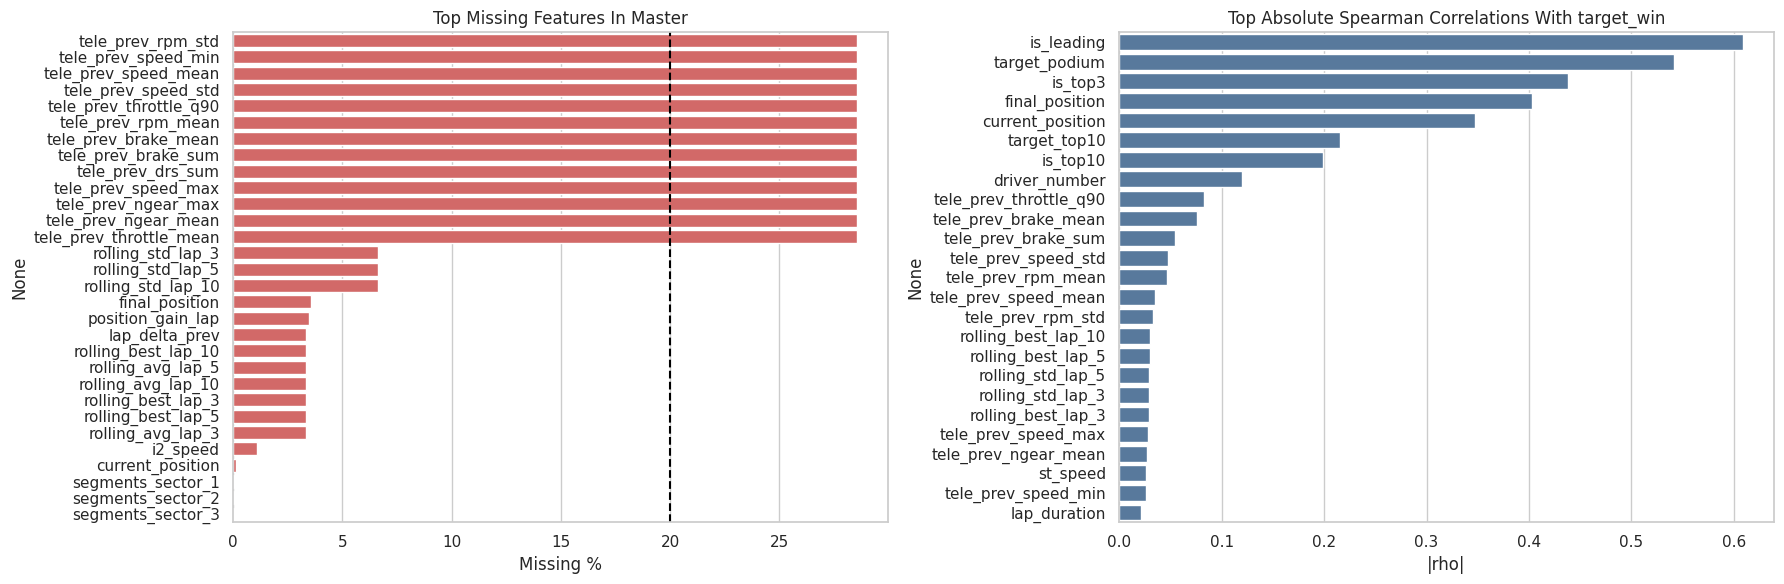

In [35]:

if not master.empty:
    miss = (master.isna().mean() * 100).sort_values(ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(y=miss.head(30).index, x=miss.head(30).values, ax=axes[0], color="#E45756")
    axes[0].axvline(20, color="black", ls="--")
    axes[0].set_title("Top Missing Features In Master")
    axes[0].set_xlabel("Missing %")

    numeric = master.select_dtypes(include=[np.number])
    if "target_win" in numeric.columns:
        corr = numeric.corr(method="spearman")["target_win"].drop("target_win").dropna().abs().sort_values(ascending=False).head(25)
        sns.barplot(y=corr.index, x=corr.values, ax=axes[1], color="#4C78A8")
        axes[1].set_title("Top Absolute Spearman Correlations With target_win")
        axes[1].set_xlabel("|rho|")
    plt.tight_layout()
    plt.show()


In [36]:

label_like = ["final_position", "target_win", "target_podium", "target_top10", "position_gain_lap", "current_position"]
leakage_table = []
for col in label_like:
    if col in master.columns:
        leakage_table.append({
            "column": col,
            "role": "label/post-session/in-race state",
            "recommendation": "Keep for evaluation/labeling or live in-race model only; exclude from pre-race model features.",
            "missing_pct": round(master[col].isna().mean() * 100, 2),
        })
display(pd.DataFrame(leakage_table))

feature_groups = pd.DataFrame([
    {"group": "Pre-race", "examples": "sessions, meetings, drivers, starting_grid, historical aggregates", "safe_for_pre_race": True},
    {"group": "Live lap-level", "examples": "past laps rolling stats, previous telemetry, weather asof, position asof", "safe_for_pre_race": False},
    {"group": "Strategy/event", "examples": "pit/stint/race_control/overtakes/team_radio up to current timestamp", "safe_for_pre_race": False},
    {"group": "Labels/results", "examples": "session_results, final_position, target_*", "safe_for_pre_race": False},
])
display(feature_groups)


,column,role,recommendation,missing_pct
0,final_position,label/post-session/in-race state,Keep for evaluation/labeling or live in-race m...,3.57
1,target_win,label/post-session/in-race state,Keep for evaluation/labeling or live in-race m...,0.00
2,target_podium,label/post-session/in-race state,Keep for evaluation/labeling or live in-race m...,0.00
3,target_top10,label/post-session/in-race state,Keep for evaluation/labeling or live in-race m...,0.00
4,position_gain_lap,label/post-session/in-race state,Keep for evaluation/labeling or live in-race m...,3.45
5,current_position,label/post-session/in-race state,Keep for evaluation/labeling or live in-race m...,0.14


,group,examples,safe_for_pre_race
0,Pre-race,"sessions, meetings, drivers, starting_grid, hi...",True
1,Live lap-level,"past laps rolling stats, previous telemetry, w...",False
2,Strategy/event,pit/stint/race_control/overtakes/team_radio up...,False
3,Labels/results,"session_results, final_position, target_*",False


,meeting_key,session_key,driver_number,lap_number,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,lap_duration,...,loc_prev_y_std,loc_prev_z_min,loc_prev_z_max,loc_prev_z_std,loc_prev_loc_bbox_area,loc_prev_loc_spread_xy,final_position,target_win,target_podium,target_top10
meeting_key,1.000,0.844,0.037,-0.025,-0.047,0.008,0.020,-0.064,0.002,-0.021,...,0.700,0.833,0.862,-0.750,0.764,0.704,-0.013,-0.000,-0.001,-0.001
session_key,0.844,1.000,0.028,-0.019,-0.014,-0.033,0.070,-0.108,-0.010,0.017,...,0.701,0.833,0.862,-0.750,0.764,0.705,-0.013,-0.001,-0.003,-0.004
driver_number,0.037,0.028,1.000,0.001,-0.003,0.008,0.004,-0.001,0.002,0.005,...,0.021,0.019,0.020,-0.017,-0.006,0.020,0.039,-0.118,-0.103,-0.017
lap_number,-0.025,-0.019,0.001,1.000,-0.178,-0.122,-0.199,0.113,0.108,-0.282,...,0.072,-0.016,-0.021,-0.024,-0.048,0.084,-0.030,0.008,0.014,0.031
duration_sector_1,-0.047,-0.014,-0.003,-0.178,1.000,0.280,0.219,-0.255,-0.068,0.668,...,-0.011,-0.001,-0.005,-0.004,0.008,-0.013,0.039,-0.015,-0.020,-0.029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
loc_prev_loc_spread_xy,0.704,0.705,0.020,0.084,-0.013,-0.047,-0.003,-0.013,0.060,-0.065,...,0.963,0.783,0.819,-0.695,0.714,1.000,-0.012,-0.002,-0.010,-0.005
final_position,-0.013,-0.013,0.039,-0.030,0.039,0.046,0.003,0.009,-0.007,0.040,...,-0.015,-0.049,-0.047,0.055,-0.076,-0.012,1.000,-0.403,-0.656,-0.857
target_win,-0.000,-0.001,-0.118,0.008,-0.015,-0.015,-0.011,0.000,-0.002,-0.021,...,0.000,0.014,0.016,-0.023,0.030,-0.002,-0.403,1.000,0.541,0.216
target_podium,-0.001,-0.003,-0.103,0.014,-0.020,-0.020,-0.016,0.001,-0.001,-0.030,...,-0.008,0.014,0.016,-0.026,0.036,-0.010,-0.656,0.541,1.000,0.398


,feature_a,feature_b,spearman_rho,abs_rho
3128,race_control_events_before_lap,race_control_events_so_far,1.000000,1.000000
2738,pit_stop_count_before_lap,pit_stop_count_so_far,1.000000,1.000000
2545,pit_duration_sum_current_lap,lane_duration_mean_current_lap,1.000000,1.000000
2594,pit_duration_mean_current_lap,lane_duration_mean_current_lap,1.000000,1.000000
2499,pit_stop_count_current_lap,is_pit_current_lap,1.000000,1.000000
2543,pit_duration_sum_current_lap,pit_duration_mean_current_lap,1.000000,1.000000
3038,yellow_flag_events_current_lap,yellow_flag_active_current_lap,0.999588,0.999588
1745,rolling_best_lap_5,rolling_best_lap_10,0.991503,0.991503
1550,rolling_best_lap_3,rolling_best_lap_5,0.976091,0.976091
1616,rolling_avg_lap_5,rolling_avg_lap_10,0.970052,0.970052


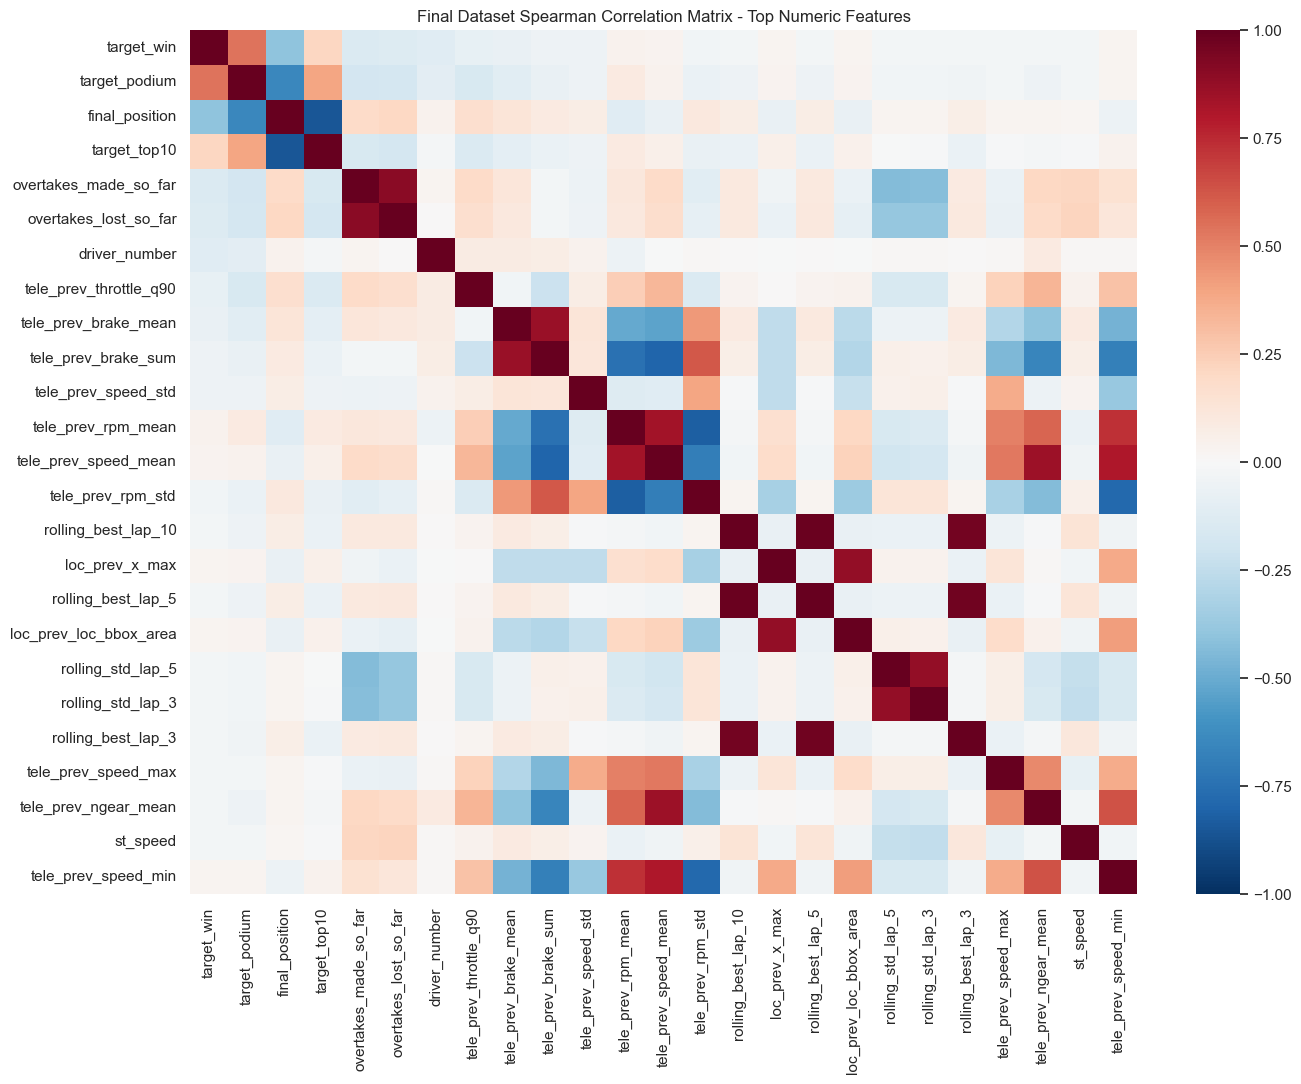

In [3]:
# Final dataset numeric correlation matrix
# This table uses the final master dataset and focuses on numeric columns only.
# It is useful for detecting redundant features, target leakage candidates, and strong feature groups.

if 'master' not in globals() or master.empty:
    master_path = PROC_DIR / 'master_dataset.parquet'
    if master_path.exists():
        master = pd.read_parquet(master_path)
    else:
        master = pd.read_csv(PROC_DIR / 'master_dataset.csv', low_memory=False)

numeric = master.select_dtypes(include=[np.number]).copy()
exclude_patterns = ('is_invalid_', 'is_missing_')
keep_cols = [c for c in numeric.columns if not c.startswith(exclude_patterns)]
numeric = numeric[keep_cols]

if numeric.shape[1] < 2:
    print('Not enough numeric columns for correlation analysis.')
else:
    corr = numeric.corr(method='spearman')
    display(corr.round(3))

    pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
    pairs.columns = ['feature_a', 'feature_b', 'spearman_rho']
    pairs['abs_rho'] = pairs['spearman_rho'].abs()
    top_pairs = pairs.sort_values('abs_rho', ascending=False).head(40)
    display(top_pairs)

    cols_for_heatmap = []
    if 'target_win' in corr.columns:
        cols_for_heatmap = corr['target_win'].abs().sort_values(ascending=False).head(25).index.tolist()
    else:
        cols_for_heatmap = numeric.var(numeric_only=True).sort_values(ascending=False).head(25).index.tolist()

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(corr.loc[cols_for_heatmap, cols_for_heatmap], cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title('Final Dataset Spearman Correlation Matrix - Top Numeric Features')
    plt.tight_layout()
    plt.show()



## Deep EDA Summary Checklist

- Endpoint grains are explicit before joins.
- High-volume telemetry/location are sampled, not loaded wholesale.
- Result columns are treated as labels/outcomes.
- Cross-endpoint plots focus on feature usefulness: pace, strategy, weather, race events, position volatility.
- The next modeling step should create separate feature lists for pre-race prediction and live in-race prediction.
